# FM-PCC Colab Workflow

---

## Run Order
1. Mount Drive
2. Clone/Update FM-PCC
3. Boost startup cache wiring
4. Install Miniconda + Create `FMPCC` env
5. Install D3IL
6. Install requirements with pinned compatibility
7. Set runtime env variables
8. Optional W&B relogin
9. Verify dependencies
10. Prepare dataset
11. Smoke test
12. Full train
13. Eval + visualization
14. Archive logs



In [1]:
# @title Notebook Version Marker
from datetime import datetime
import pytz

# Change 'UTC' to your local timezone if preferred (e.g., 'US/Eastern', 'Asia/Shanghai')
TIMEZONE = 'UTC'

now = datetime.now(pytz.timezone(TIMEZONE))
version_mark = now.strftime("%Y.%m.%d_%H%M%S")

print("=" * 40)
print(f"SESSION VERSION: {version_mark}")
print(f"START TIME     : {now.strftime('%A, %b %d, %Y - %I:%M:%S %p %Z')}")
print("=" * 40)

SESSION VERSION: 2026.03.30_095737
START TIME     : Monday, Mar 30, 2026 - 09:57:37 AM UTC


## 1) Mount Google Drive



In [2]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

FMPCC_ROOT = '/content/drive/MyDrive/FMPCC'
REPO = f'{FMPCC_ROOT}/FM-PCC'
os.makedirs(FMPCC_ROOT, exist_ok=True)

print('Drive mounted')
print('Repo path:', REPO)



Mounted at /content/drive
Drive mounted
Repo path: /content/drive/MyDrive/FMPCC/FM-PCC


## 2) Clone or Update FM-PCC



In [3]:
# @title Git Repository Sync
# @markdown Set this to 1 to replace any edited GitHub files with the latest versions.
# @markdown Your new files/notes will NOT be deleted.
OVERWRITE_LOCAL_CHANGES = "1" # @param [0, 1]
UPDATE_REPO = 1 # @param [0, 1]

import os
os.environ['OVERWRITE_LOCAL_CHANGES'] = str(OVERWRITE_LOCAL_CHANGES)
os.environ['UPDATE_REPO'] = str(UPDATE_REPO)

In [4]:
%%bash
set -e

ROOT="/content/drive/MyDrive/FMPCC"
REPO="$ROOT/FM-PCC"
BRANCH="main" # You can change this if you ever decide to switch branches

mkdir -p "$ROOT"
cd "$ROOT"

if [ ! -d "$REPO/.git" ]; then
  echo "Cloning fresh repository..."
  git clone --recurse-submodules https://github.com/ghubliming/FM-PCC.git
else
  cd "$REPO"

  if [ "$UPDATE_REPO" != "1" ]; then
    echo "Repo update disabled. Using existing local checkout."
  else
    echo "Fetching latest updates from GitHub..."
    git fetch origin "$BRANCH"

    if [ "$OVERWRITE_LOCAL_CHANGES" = "1" ]; then
      echo "OVERWRITE_LOCAL_CHANGES=1: Resetting tracked files to match remote."
      # This command ONLY affects files that exist in the Git repo.
      # It does NOT touch your new notes or results.
      git reset --hard "origin/$BRANCH"
      git submodule update --init --recursive
    else
      # Check if there are any local edits to GitHub files
      CHANGED_FILES="$(git status --porcelain | grep '^ M' || true)"
      if [ -n "$CHANGED_FILES" ]; then
        echo "WARNING: Local edits detected in GitHub files. Skipping update to protect them."
        echo "Set OVERWRITE_LOCAL_CHANGES=1 to replace these files with the remote version."
      else
        echo "No conflicts found. Updating..."
        git merge "origin/$BRANCH"
        git submodule update --init --recursive
      fi
    fi
  fi
fi

echo "------------------------------------------------"
echo "Repo ready: $REPO"
echo "Current Branch: $(git branch --show-current)"
echo "------------------------------------------------"

# This part specifically shows you what is yours (notes/new files)
echo "Your Local Notes & New Files (Not in Git):"
UNTRACKED="$(git ls-files --others --exclude-standard)"
if [ -z "$UNTRACKED" ]; then
  echo "  (None)"
else
  echo "$UNTRACKED"
fi

Fetching latest updates from GitHub...
OVERWRITE_LOCAL_CHANGES=1: Resetting tracked files to match remote.
HEAD is now at 06f9756 Merge pull request #3 from ghubliming/update_into_FM
------------------------------------------------
Repo ready: /content/drive/MyDrive/FMPCC/FM-PCC
Current Branch: main
------------------------------------------------
Your Local Notes & New Files (Not in Git):
FM_test/load_results_FM.py
d3il/
logs_in_develop/load_results_outputs/seed5_DPCC/success_rates.png
logs_in_develop/load_results_outputs/seed5_DPCC/success_rates_tightened.png
logs_in_develop/load_results_outputs/seed5_DPCC/timesteps.png
logs_in_develop/load_results_outputs/seed5_DPCC/timesteps_tightened.png
logs_in_develop/load_results_outputs/seed6_DPCC/success_rates.png
logs_in_develop/load_results_outputs/seed6_DPCC/success_rates_tightened.png
logs_in_develop/load_results_outputs/seed6_DPCC/timesteps.png
logs_in_develop/load_results_outputs/seed6_DPCC/timesteps_tightened.png
logs_in_develop/load_r

From https://github.com/ghubliming/FM-PCC
 * branch            main       -> FETCH_HEAD
Updating files: 100% (185/185), done.


## 3) Boost Startup Cache Wiring

Keeps the original `/content/miniconda3` path logic, but maps it to Drive so restarts can reuse the same conda env and pip cache.



In [3]:
%%bash
set -e

ROOT="/content/drive/MyDrive/FMPCC"
PERSIST_CONDA="$ROOT/miniconda3"
RUNTIME_CONDA="/content/miniconda3"
PIP_CACHE="$ROOT/.pip-cache"

mkdir -p "$ROOT" "$PIP_CACHE"

if [ -L "$RUNTIME_CONDA" ]; then
  rm -f "$RUNTIME_CONDA"
elif [ -d "$RUNTIME_CONDA" ]; then
  rm -rf "$RUNTIME_CONDA"
fi

ln -s "$PERSIST_CONDA" "$RUNTIME_CONDA"

echo "Runtime conda path mapped to: $PERSIST_CONDA"
echo "Persistent pip cache path: $PIP_CACHE"



Runtime conda path mapped to: /content/drive/MyDrive/FMPCC/miniconda3
Persistent pip cache path: /content/drive/MyDrive/FMPCC/.pip-cache


## 4) Install Miniconda and Create Env

Keeps Python pinned to 3.10 for compatibility with project dependencies.



In [4]:
%%bash
set -e

ROOT="/content/drive/MyDrive/FMPCC"
PERSIST_CONDA="$ROOT/miniconda3"
RUNTIME_CONDA="/content/miniconda3"
CONDA_BIN="$PERSIST_CONDA/bin/conda"
LOCAL_FALLBACK_CONDA="/content/miniconda3_runtime"
CONDA_SNAPSHOT_DIR="$ROOT/cache"
CONDA_SNAPSHOT="$CONDA_SNAPSHOT_DIR/fmpcc_conda_env.tar.gz"
FORCE_REINSTALL_CONDA="${FORCE_REINSTALL_CONDA:-0}"
REFRESH_CONDA_SNAPSHOT="${REFRESH_CONDA_SNAPSHOT:-0}"

# Ensure the runtime path points to the persistent conda directory.
if [ -L "$RUNTIME_CONDA" ]; then
  LINK_TARGET="$(readlink -f "$RUNTIME_CONDA" || true)"
  if [ "$LINK_TARGET" != "$PERSIST_CONDA" ]; then
    rm -f "$RUNTIME_CONDA"
    ln -s "$PERSIST_CONDA" "$RUNTIME_CONDA"
  fi
elif [ ! -e "$RUNTIME_CONDA" ]; then
  ln -s "$PERSIST_CONDA" "$RUNTIME_CONDA"
fi

if [ "$FORCE_REINSTALL_CONDA" = "1" ]; then
  echo "FORCE_REINSTALL_CONDA=1 -> reinstalling Miniconda"
  rm -rf "$PERSIST_CONDA"
fi

if [ ! -d "$PERSIST_CONDA" ]; then
  echo "First run detected: no persistent conda directory yet"
fi

# 1) Check if conda exists and works.
NEED_CONDA_INSTALL=0
if [ -x "$CONDA_BIN" ]; then
  chmod +x "$PERSIST_CONDA/bin/python" "$PERSIST_CONDA/bin/conda" || true
  if ! "$CONDA_BIN" --version >/tmp/conda_check.log 2>&1; then
    if grep -qi "Permission denied" /tmp/conda_check.log; then
      echo "Drive conda is not executable (permission denied). Switching to local runtime conda."
      if [ -L "$RUNTIME_CONDA" ] || [ -e "$RUNTIME_CONDA" ]; then
        rm -rf "$RUNTIME_CONDA"
      fi
      ln -s "$LOCAL_FALLBACK_CONDA" "$RUNTIME_CONDA"
      PERSIST_CONDA="$LOCAL_FALLBACK_CONDA"
      CONDA_BIN="$PERSIST_CONDA/bin/conda"
      if [ -x "$CONDA_BIN" ]; then
        echo "Reusing existing local runtime conda."
      else
        echo "No local runtime conda found yet; it will be installed now."
        NEED_CONDA_INSTALL=1
      fi
    else
      echo "Conda exists but failed health check -> reinstalling"
      rm -rf "$PERSIST_CONDA"
      NEED_CONDA_INSTALL=1
    fi
  else
    echo "Conda exists and passed health check -> skip reinstall"
  fi
else
  NEED_CONDA_INSTALL=1
fi

# 2) If there is a problem, reinstall.
if [ "$NEED_CONDA_INSTALL" = "1" ]; then
  if [ -f "$CONDA_SNAPSHOT" ]; then
    echo "Restoring conda snapshot: $CONDA_SNAPSHOT"
    rm -rf "$PERSIST_CONDA"
    mkdir -p "$PERSIST_CONDA"
    if ! tar -xzf "$CONDA_SNAPSHOT" -C "$PERSIST_CONDA" --strip-components=1; then
      echo "Snapshot restore failed -> will run installer fallback"
      rm -rf "$PERSIST_CONDA"
    fi
  fi

  if [ ! -x "$CONDA_BIN" ] || ! "$CONDA_BIN" --version >/dev/null 2>&1; then
    echo "Conda snapshot missing/broken -> installing Miniconda"
    wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /content/miniconda.sh
    bash /content/miniconda.sh -b -p "$PERSIST_CONDA" -u
  else
    echo "Conda restored from snapshot"
  fi
fi

"$CONDA_BIN" tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
"$CONDA_BIN" tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

if ! "$CONDA_BIN" env list | grep -q "^FMPCC "; then
  "$CONDA_BIN" create -n FMPCC python=3.10 -y -q
fi

if [ ! -x "$PERSIST_CONDA/envs/FMPCC/bin/python" ] || [ ! -x "$PERSIST_CONDA/envs/FMPCC/bin/pip" ]; then
  "$CONDA_BIN" remove -n FMPCC --all -y || true
  "$CONDA_BIN" create -n FMPCC python=3.10 -y -q
fi

# If env binaries on Drive are not executable, switch to local runtime conda and rebuild env there.
if ! "$PERSIST_CONDA/envs/FMPCC/bin/python" -V >/tmp/env_python_check.log 2>&1; then
  if grep -qi "Permission denied" /tmp/env_python_check.log; then
    echo "FMPCC env python is not executable on current path. Switching env to local runtime conda."
    if [ -L "$RUNTIME_CONDA" ] || [ -e "$RUNTIME_CONDA" ]; then
      rm -rf "$RUNTIME_CONDA"
    fi
    ln -s "$LOCAL_FALLBACK_CONDA" "$RUNTIME_CONDA"
    PERSIST_CONDA="$LOCAL_FALLBACK_CONDA"
    CONDA_BIN="$PERSIST_CONDA/bin/conda"

    if [ ! -x "$CONDA_BIN" ]; then
      wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /content/miniconda.sh
      bash /content/miniconda.sh -b -p "$PERSIST_CONDA" -u
    fi

    "$CONDA_BIN" tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
    "$CONDA_BIN" tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
    "$CONDA_BIN" remove -n FMPCC --all -y || true
    "$CONDA_BIN" create -n FMPCC python=3.10 -y -q
  else
    cat /tmp/env_python_check.log
    exit 1
  fi
fi

"$PERSIST_CONDA/envs/FMPCC/bin/python" -V
"$PERSIST_CONDA/envs/FMPCC/bin/pip" --version

# Save a conda snapshot for fast restore on future Colab runtimes.
mkdir -p "$CONDA_SNAPSHOT_DIR"
if [ ! -f "$CONDA_SNAPSHOT" ] || [ "$REFRESH_CONDA_SNAPSHOT" = "1" ]; then
  echo "Creating conda snapshot: $CONDA_SNAPSHOT"
  if ! tar -czf "$CONDA_SNAPSHOT" -C "$PERSIST_CONDA" .; then
    echo "Snapshot creation failed -> continuing without cache update"
  fi
else
  echo "Conda snapshot exists -> skipping snapshot refresh"
fi



Conda exists and passed health check -> skip reinstall
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
FMPCC env python is not executable on current path. Switching env to local runtime conda.
PREFIX=/content/miniconda3_runtime
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /content/miniconda3_runtime
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channe


EnvironmentLocationNotFound: Not a conda environment: /content/miniconda3_runtime/envs/FMPCC



## 5) Install D3IL (Install Once + Verify)

Uses editable installs for both D3IL core and `gym_avoiding_env`, but skips reinstall when editable links already exist.



In [5]:
%%bash
set -e

PIP="/content/miniconda3/envs/FMPCC/bin/pip"
REPO="/content/drive/MyDrive/FMPCC/FM-PCC"
D3IL="$REPO/d3il"

if [ ! -d "$D3IL/.git" ]; then
  echo "d3il missing/incomplete -> recloning"
  rm -rf "$D3IL"
  git clone https://github.com/ALRhub/d3il.git "$D3IL"
fi

if "$PIP" freeze | grep -Fq "d3il/environments/d3il" && "$PIP" freeze | grep -Fq "d3il/envs/gym_avoiding_env"; then
  echo "D3IL editable installs already present; skipping reinstall"
else
  "$PIP" install -e "$D3IL/environments/d3il"
  "$PIP" install -e "$D3IL/environments/d3il/envs/gym_avoiding_env"
fi

echo "D3IL installed"



Obtaining file:///content/drive/MyDrive/FMPCC/FM-PCC/d3il/environments/d3il
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for environments.d3il.d3il_sim (pyproject.toml): started
  Building editable for environments.d3il.d3il_sim (pyproject.toml): finished with status 'done'
  Created wheel for environments.d3il.d3il_sim: filename=environments_d3il_d3il_sim-0.2-0.editable-py3-none-any.whl size=2970 sha256=797e84ca0c01b8cd58e2102b874231d1d91dfc56d588a6346b716d00d52a7157
  Stored in directory: /tmp/pip-ephem-wheel-cache-6k2msf

## 6) Install Requirements (Install Once + Verify)

Runs validation first and only installs when the environment is missing or inconsistent.



In [6]:
%%bash
set -e

REPO="/content/drive/MyDrive/FMPCC/FM-PCC"
PIP="/content/miniconda3/envs/FMPCC/bin/pip"
PY="/content/miniconda3/envs/FMPCC/bin/python"
PIP_CACHE="/content/drive/MyDrive/FMPCC/.pip-cache"
CACHE_DIR="/content/drive/MyDrive/FMPCC/cache"
REQ_FILE="$REPO/requirements.txt"
REQ_HASH="$(sha256sum "$REQ_FILE" | awk '{print $1}')"
WHEELHOUSE="$CACHE_DIR/wheelhouse_$REQ_HASH"
REQ_STAMP="/content/miniconda3/envs/FMPCC/.fmpcc_requirements_hash"
FORCE_REINSTALL_REQS="${FORCE_REINSTALL_REQS:-0}"

mkdir -p "$PIP_CACHE" "$CACHE_DIR"
cd "$REPO"

if [ "$FORCE_REINSTALL_REQS" = "1" ]; then
  echo "FORCE_REINSTALL_REQS=1 -> forcing requirements reinstall"
  REQ_VALID=0
elif "$PY" - <<'PY'
import importlib
import sys

pkgs = [
    'torch', 'numpy', 'scipy', 'gym', 'gymnasium', 'gymnasium_robotics',
    'minari', 'wandb', 'mujoco', 'diffusers', 'transformers'
]

ok = True
for p in pkgs:
    try:
        importlib.import_module(p)
    except Exception as e:
        ok = False
        print(f'Missing/broken package: {p} ({type(e).__name__}: {e})')

import numpy
if int(numpy.__version__.split('.')[0]) >= 2:
    ok = False
    print(f'Invalid numpy version: {numpy.__version__}; expected 1.x for this workflow')

sys.exit(0 if ok else 2)
PY
then
  REQ_VALID=1
else
  REQ_VALID=0
fi

if [ "$REQ_VALID" = "1" ]; then
  if [ -f "$REQ_STAMP" ] && grep -Fxq "$REQ_HASH" "$REQ_STAMP"; then
    echo "Package validation passed and requirements hash unchanged; skipping reinstall"
  else
    echo "Package validation passed but requirements hash stamp missing/changed; updating stamp only"
    echo "$REQ_HASH" > "$REQ_STAMP"
  fi
else
  echo "Package validation failed; installing requirements"

  # Build or reuse a Drive-backed wheelhouse for faster future reinstalls.
  if [ ! -d "$WHEELHOUSE" ] || [ -z "$(ls -A "$WHEELHOUSE" 2>/dev/null || true)" ]; then
    echo "Building wheelhouse cache at: $WHEELHOUSE"
    mkdir -p "$WHEELHOUSE"
    PIP_CACHE_DIR="$PIP_CACHE" "$PIP" download -r requirements.txt -d "$WHEELHOUSE" || true
  else
    echo "Wheelhouse cache found: $WHEELHOUSE"
  fi

  WHEEL_COUNT="$(find "$WHEELHOUSE" -maxdepth 1 -type f \( -name '*.whl' -o -name '*.tar.gz' -o -name '*.zip' \) | wc -l)"
  if [ "$WHEEL_COUNT" -gt 0 ] && PIP_CACHE_DIR="$PIP_CACHE" "$PIP" install --no-index --find-links "$WHEELHOUSE" -r requirements.txt; then
    echo "Offline wheelhouse install succeeded"
  else
    echo "First run or incomplete wheelhouse -> running online install"
    PIP_CACHE_DIR="$PIP_CACHE" "$PIP" install -r requirements.txt

    # Backfill wheelhouse after a successful online install for faster future runs.
    PIP_CACHE_DIR="$PIP_CACHE" "$PIP" download -r requirements.txt -d "$WHEELHOUSE" || true
  fi

  # pip check may report known non-fatal issues on Colab (platform/extra metadata).
  PIP_CHECK_OUT="$("$PIP" check 2>&1 || true)"
  echo "$PIP_CHECK_OUT"

  UNEXPECTED_PIP_CHECK="$(echo "$PIP_CHECK_OUT" | grep -Ev '(^$|gurobipy .* is not supported on this platform|WARNING: typer .* does not provide the extra .all.)' || true)"
  if [ -n "$UNEXPECTED_PIP_CHECK" ]; then
    echo "Unexpected pip check issues found:"
    echo "$UNEXPECTED_PIP_CHECK"
    exit 1
  else
    echo "Only known non-fatal pip check warnings detected; continuing"
  fi

  echo "$REQ_HASH" > "$REQ_STAMP"
fi

# Quick sanity check
"$PY" - <<'PY'
import numpy, torch
print("numpy:", numpy.__version__)
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("python:", __import__("sys").executable)
PY



Missing/broken package: torch (ModuleNotFoundError: No module named 'torch')
Missing/broken package: scipy (ModuleNotFoundError: No module named 'scipy')
Missing/broken package: gymnasium (ModuleNotFoundError: No module named 'gymnasium')
Missing/broken package: gymnasium_robotics (ModuleNotFoundError: No module named 'gymnasium_robotics')
Missing/broken package: minari (ModuleNotFoundError: No module named 'minari')
Missing/broken package: mujoco (ModuleNotFoundError: No module named 'mujoco')
Missing/broken package: diffusers (ModuleNotFoundError: No module named 'diffusers')
Missing/broken package: transformers (ModuleNotFoundError: No module named 'transformers')
Invalid numpy version: 2.2.6; expected 1.x for this workflow
Package validation failed; installing requirements
Wheelhouse cache found: /content/drive/MyDrive/FMPCC/cache/wheelhouse_7f51b2eecd675d29f593a4ec70084ed4251266c758f7a4374628942b33efaa39
Looking in links: /content/drive/MyDrive/FMPCC/cache/wheelhouse_7f51b2eecd675

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 7) Runtime Environment Variables

Includes W&B malformed service cleanup and Colab rendering settings.



In [7]:
import os

FMPCC = '/content/drive/MyDrive/FMPCC/FM-PCC'
D3IL_ROOT = f'{FMPCC}/d3il'
GYM_AV = f'{D3IL_ROOT}/environments/d3il/envs/gym_avoiding_env'

existing_pp = os.environ.get('PYTHONPATH', '')
parts = [FMPCC, D3IL_ROOT, GYM_AV]
if existing_pp:
    parts.append(existing_pp)

os.environ['FMPCC'] = FMPCC
os.environ['PYTHONPATH'] = ':'.join(parts)
os.environ['MUJOCO_GL'] = 'egl'
os.environ['PYOPENGL_PLATFORM'] = 'egl'
os.environ['MPLBACKEND'] = 'agg'

for key in ('WANDB_SERVICE', 'WANDB__SERVICE'):
    os.environ.pop(key, None)

os.chdir(FMPCC)
print('cwd:', os.getcwd())
print('PYTHONPATH:', os.environ['PYTHONPATH'])



cwd: /content/drive/MyDrive/FMPCC/FM-PCC
PYTHONPATH: /content/drive/MyDrive/FMPCC/FM-PCC:/content/drive/MyDrive/FMPCC/FM-PCC/d3il:/content/drive/MyDrive/FMPCC/FM-PCC/d3il/environments/d3il/envs/gym_avoiding_env:/env/python


## 8) Optional W&B Login



In [8]:
import os
from pathlib import Path
import wandb

KEY_FILE = Path('/content/drive/MyDrive/FMPCC/.wandb_api_key')

if not KEY_FILE.exists():
    raise FileNotFoundError(
        f'Missing W&B key file: {KEY_FILE}. Create it with your API key on one line.'
    )

api_key = KEY_FILE.read_text(encoding='utf-8').strip()
if not api_key:
    raise ValueError(f'W&B key file is empty: {KEY_FILE}')

for k in ('WANDB_SERVICE', 'WANDB__SERVICE'):
    os.environ.pop(k, None)

wandb.finish()
os.environ['WANDB_MODE'] = 'online'
os.environ['WANDB_API_KEY'] = api_key

wandb.login(key=api_key, relogin=True)

print('W&B mode:', os.environ.get('WANDB_MODE'))
print('W&B key file:', KEY_FILE)
print('W&B key loaded:', f'***{api_key[-4:]}' if len(api_key) >= 4 else '***')



/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: llmmail2021 (llmmail2021-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B mode: online
W&B key file: /content/drive/MyDrive/FMPCC/.wandb_api_key
W&B key loaded: ***KogM


## 9) Full Verification

Validates import chain with the exact env interpreter used for training.



In [9]:
%%bash
set -e

/content/miniconda3/envs/FMPCC/bin/python - <<'PY'
import importlib
import sys

pkgs = [
    'torch', 'numpy', 'scipy', 'gym', 'gymnasium', 'gymnasium_robotics',
    'minari', 'wandb', 'mujoco', 'diffusers', 'transformers'
]

ok = True
for p in pkgs:
    try:
        m = importlib.import_module(p)
        v = getattr(m, '__version__', 'unknown')
        print(f'{p:20s} {v}')
    except Exception as e:
        ok = False
        print(f'{p:20s} NOT IMPORTABLE ({type(e).__name__}: {e})')

import numpy, torch
print('numpy pinned:', numpy.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))

major = int(numpy.__version__.split('.')[0])
if major >= 2:
    ok = False
    print('ERROR: numpy 2.x detected, expected 1.26.4 for this workflow')

if not ok:
    sys.exit(2)
PY



torch                2.2.2+cu121
numpy                1.26.4
scipy                1.13.1
gym                  0.26.2
gymnasium            0.29.1
gymnasium_robotics   1.2.4
minari               0.4.3
wandb                0.17.5
mujoco               2.3.7
diffusers            0.31.0
transformers         4.41.2
numpy pinned: 1.26.4
cuda available: True
device: Tesla T4


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]


## 10) Dataset Preparation (Avoiding)

### Option A: Use existing zip from old DPCC path

Warning! : It searches the ~15Gb Zip in the DPCC Path, not this FMPCC Path!


This exits quickly if avoiding data already exists.



In [12]:
%%bash
set -e

REPO="/content/drive/MyDrive/FMPCC/FM-PCC"
AVOIDING_DATA="$REPO/d3il/environments/dataset/data/avoiding/data"
DATA_ZIP="/content/drive/MyDrive/DPCC/dpcc/d3il/environments/dataset/data/dataset.zip"

if [ -d "$AVOIDING_DATA" ] && [ "$(ls -A "$AVOIDING_DATA")" ]; then
  echo "avoiding data already present: $(ls "$AVOIDING_DATA" | wc -l) files"
  exit 0
fi

if [ ! -f "$DATA_ZIP" ]; then
  echo "dataset zip not found: $DATA_ZIP"
  echo "Skip this cell and use Option B below if needed."
  exit 1
fi

TMP="/content/avoiding_tmp"
rm -rf "$TMP"
mkdir -p "$TMP"
unzip -q "$DATA_ZIP" "avoiding/*" -d "$TMP"
mkdir -p "$REPO/d3il/environments/dataset/data/avoiding"
cp -r "$TMP/avoiding/." "$REPO/d3il/environments/dataset/data/avoiding/"
rm -rf "$TMP"

echo "avoiding dataset ready: $(ls "$AVOIDING_DATA" | wc -l) files"



avoiding data already present: 96 files


### Option B: Download full D3IL dataset zip with gdown (only if Option A unavailable)



```
%%bash
set -e

REPO="/content/drive/MyDrive/FMPCC/FM-PCC"
DATA_DIR="$REPO/d3il/environments/dataset/data"
ZIP_FILE="$DATA_DIR/dataset.zip"

if [ -f "$ZIP_FILE" ]; then
  echo "zip already exists: $ZIP_FILE"
  exit 0
fi

/content/miniconda3/envs/FMPCC/bin/pip install gdown -q
/content/miniconda3/envs/FMPCC/bin/python -m gdown \
  "https://drive.google.com/uc?id=1SQhbhzV85zf_ltnQ8Cbge2lsSWInxVa8" \
  -O "$ZIP_FILE"

echo "downloaded zip: $ZIP_FILE"



## 11) Smoke Test Train

Short check before full run.



## 12) Full Train

Real-time streaming via `!python`.



In [ ]:
#!/content/miniconda3/envs/FMPCC/bin/python scripts/train.py --seeds 6 --num-seeds 1 --use-wandb --wandb-project FMPCC

!/content/miniconda3/envs/FMPCC/bin/python FM_test/train_FM.py --seeds 5 --num-seeds 1 --use-wandb --wandb-project FMPCC


[ train ] Seed source: cli --seeds
[ train ] Training seeds: [5]
[ utils/setup ] Made savepath: logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5
[ train ] Saved seed manifest to: logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/seeds_config.json
wandb: Currently logged in as: llmmail2021 (llmmail2021-technical-university-of-munich). Use `wandb login --relogin` to force relogin
wandb: wandb version 0.25.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.5
wandb: Run data is saved locally in /content/drive/MyDrive/FMPCC/FM-PCC/wandb/run-20260328_104831-9afyk0u1
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run avoiding-d3il-seed-5
wandb: ⭐️ View project at https://wandb.ai/llmmail2021-technical-university-of-munich/FMPCC
wandb: 🚀 View run at https://wandb.ai/llmmail2021-technical-university-of-munich/FMPCC/runs/9afyk0u1

[utils/config ] Config: 

## 13) Resume Training (Optional)



In [10]:
#!/content/miniconda3/envs/FMPCC/bin/python scripts/train.py --seeds 5 --auto-resume --use-wandb --wandb-project FMPCC
!/content/miniconda3/envs/FMPCC/bin/python FM_test/train_FM.py --seeds 5 --auto-resume --use-wandb --wandb-project FMPCC

[ train ] Seed source: cli --seeds
[ train ] Training seeds: [5]
[ train ] Saved seed manifest to: logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/seeds_config.json
wandb: Currently logged in as: llmmail2021 (llmmail2021-technical-university-of-munich). Use `wandb login --relogin` to force relogin
wandb: wandb version 0.25.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.5
wandb: Run data is saved locally in /content/drive/MyDrive/FMPCC/FM-PCC/wandb/run-20260328_162351-oku7b2n0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run avoiding-d3il-seed-5
wandb: ⭐️ View project at https://wandb.ai/llmmail2021-technical-university-of-munich/FMPCC
wandb: 🚀 View run at https://wandb.ai/llmmail2021-technical-university-of-munich/FMPCC/runs/oku7b2n0

[utils/config ] Config: <class 'flow_matcher.datasets.sequence.SequenceDataset'>
    discount: 0.99
    env: avoiding-d3il
    horizo

## 14) Evaluation and Results



Remember to edit the yaml in /config to choose seeds
and
must write_to_file: True

In [ ]:
#!/content/miniconda3/envs/FMPCC/bin/python scripts/eval.py
!/content/miniconda3/envs/FMPCC/bin/python FM_test/eval_FM.py


pybullet build time: Nov 28 2023 23:45:17
[ utils/setup ] Made savepath: logs/avoiding-d3il/plans/H8_K20_Dmodels.diffusion.GaussianDiffusion/5

[ utils/serialization ] Loading model from logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5

[ datasets/buffer ] Fields:
    observations: (96, 150, 4)
    actions: (96, 150, 2)
    rewards: (96, 150, 1)
    terminals: (96, 150, 1)
    normed_observations: (96, 150, 4)
    normed_actions: (96, 150, 2)

Final IK error (78 iterations):  7.2858622740627195e-06
Final IK error (0 iterations):  7.2858622740627195e-06
------------------------Running avoiding-d3il - top-right-hard - dpcc-r (5)----------------------------
Success rate: 1.0
Constraints satisfied: 1.0
Success rate (goal and constraints): 1.0
Avg number of steps: 63.50 +- 0.50
Avg number of constraint violations: 0.00 +- 0.00
Avg total violation: 0.000 +- 0.000
Average computation time per step: 0.627
------------------------Running avoiding-d3il - top-right-ha

### Load Results

If the process crashed change the yaml to resume at crash point.

Example Save Path : `logs/avoiding-d3il/plans/H8_K20_Dmodels.GaussianDiffusion/0/results/`

In [ ]:
!/content/miniconda3/envs/FMPCC/bin/python FM_test/load_results_FM.py


## 15) Visualization



In [ ]:
!/content/miniconda3/envs/FMPCC/bin/python scripts/visualize_data_constraints.py



## 16) Archive Logs to Drive



In [ ]:
%%bash
set -e

REPO="/content/drive/MyDrive/FMPCC/FM-PCC"
STAMP="$(date +%Y%m%d_%H%M%S)"
OUT="/content/drive/MyDrive/FMPCC/runs_snapshot/$STAMP"

mkdir -p "$OUT"
if [ -d "$REPO/logs" ]; then
  cp -r "$REPO/logs" "$OUT/"
fi
if [ -d "$REPO/wandb" ]; then
  cp -r "$REPO/wandb" "$OUT/"
fi

echo "snapshot saved: $OUT"


# misc

## Load the Training Results (NOT USING CONDA)

```
# ============================================================
# WHAT WE ARE PLOTTING (4 curves across 2 subplots):
#
#   Left subplot — "Total Loss":
#     ✅ training_losses  (pkl col "training_losses"  + wandb "loss")
#     ✅ test_losses       (pkl col "test_losses"      + wandb "loss_test")
#
#   Right subplot — "a0 Loss (Action Prediction)":
#     ✅ training_a0_losses (pkl col "training_a0_losses" + wandb "a0_loss")
#     ✅ test_a0_losses     (pkl col "test_a0_losses"     + wandb "a0_loss_test")
#
# WHAT WE ARE NOT PLOTTING:
#     ❌ diffusion_loss       (available in wandb log, not plotted)
#     ❌ diffusion_loss_test   (available in wandb log, not plotted)
#     ❌ lr (learning rate)    (available in wandb log, not plotted)
#
# DATA SOURCES:
#     - losses.pkl  → late training data (~step 40000+)
#     - WANDB_LOG_TEXT (hardcoded console paste) → epochs 0-72, steps 999-72193
#     - combine() only adds wandb steps NOT already in pkl
# ============================================================

FM - 5

Part



From Wandb
```
2026-03-28 11:48:43
[utils/config ] Config: <class 'flow_matcher.datasets.sequence.SequenceDataset'>
2026-03-28 11:48:43
    discount: 0.99
2026-03-28 11:48:43
    env: avoiding-d3il
2026-03-28 11:48:43
    horizon: 8
2026-03-28 11:48:43
    include_returns: True
2026-03-28 11:48:43
    max_path_length: 150
2026-03-28 11:48:43
    normalizer: LimitsNormalizer
2026-03-28 11:48:43
    preprocess_fns: []
2026-03-28 11:48:43
    returns_scale: 150
2026-03-28 11:48:43
    use_padding: True
2026-03-28 11:48:43
[ utils/config ] Saved config to: logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5/dataset_config.pkl
2026-03-28 11:50:10
[ datasets/buffer ] Fields:
2026-03-28 11:50:10
    observations: (96, 150, 4)
2026-03-28 11:50:10
    actions: (96, 150, 2)
2026-03-28 11:50:10
    rewards: (96, 150, 1)
2026-03-28 11:50:10
    terminals: (96, 150, 1)
2026-03-28 11:50:10
    normed_observations: (96, 150, 4)
2026-03-28 11:50:10
    normed_actions: (96, 150, 2)
2026-03-28 11:50:14
[utils/config ] Config: <class 'flow_matcher.models.unet1d_temporal_cond.UNet1DTemporalCondModel'>
2026-03-28 11:50:14
    cond_dim: 4
2026-03-28 11:50:14
    condition_dropout: 0.25
2026-03-28 11:50:14
    dim: 32
2026-03-28 11:50:14
    dim_mults: (1, 2, 4, 8)
2026-03-28 11:50:14
    horizon: 8
2026-03-28 11:50:14
    returns_condition: False
2026-03-28 11:50:14
    transition_dim: 6
2026-03-28 11:50:14
[ utils/config ] Saved config to: logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5/model_config.pkl
2026-03-28 11:50:14
[utils/config ] Config: <class 'flow_matcher.models.diffusion.GaussianDiffusion'>
2026-03-28 11:50:14
    action_dim: 2
2026-03-28 11:50:14
    action_weight: 10
2026-03-28 11:50:14
    clip_denoised: False
2026-03-28 11:50:14
    condition_guidance_w: 1.2
2026-03-28 11:50:14
    goal_dim: 0
2026-03-28 11:50:14
    horizon: 8
2026-03-28 11:50:14
    loss_discount: 1.0
2026-03-28 11:50:14
    loss_type: l2
2026-03-28 11:50:14
    n_timesteps: 20
2026-03-28 11:50:14
    observation_dim: 4
2026-03-28 11:50:14
    predict_epsilon: True
2026-03-28 11:50:14
    returns_condition: False
2026-03-28 11:50:14
[ utils/config ] Saved config to: logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5/diffusion_config.pkl
2026-03-28 11:50:14
[utils/config ] Config: <class 'flow_matcher.utils.training.Trainer'>
2026-03-28 11:50:14
    ema_decay: 0.995
2026-03-28 11:50:14
    gradient_accumulate_every: 2
2026-03-28 11:50:14
    n_steps_per_epoch: 1000
2026-03-28 11:50:14
    n_train_steps: 100000.0
2026-03-28 11:50:14
    results_folder: logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5
2026-03-28 11:50:14
    train_batch_size: 8
2026-03-28 11:50:14
    train_lr: 0.0001
2026-03-28 11:50:14
    train_test_split: 0.9
2026-03-28 11:50:14
[ utils/config ] Saved config to: logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5/trainer_config.pkl
2026-03-28 11:51:37
Epoch 0: 100% 1000/1000 [01:22<00:00, 12.08it/s, a0_loss=0.052, a0_loss_test=0.156, diffusion_loss=1.12, loss=0.558, loss_test=1.02, lr=0.0001, step=999]
2026-03-28 11:50:18
Initial test loss:   1.0215, a0 loss:   0.1557
2026-03-28 11:52:57
Epoch 1: 100% 1000/1000 [01:20<00:00, 12.45it/s, a0_loss=0.0384, a0_loss_test=0.0874, diffusion_loss=0.708, loss=0.354, loss_test=0.633, lr=0.0001, step=1999]
2026-03-28 11:54:17
Epoch 2: 100% 1000/1000 [01:20<00:00, 12.36it/s, a0_loss=0.153, a0_loss_test=0.0746, diffusion_loss=1.18, loss=0.591, loss_test=0.472, lr=9.99e-5, step=2999]
2026-03-28 11:55:39
Epoch 3: 100% 1000/1000 [01:21<00:00, 12.32it/s, a0_loss=0.0471, a0_loss_test=0.0664, diffusion_loss=0.505, loss=0.252, loss_test=0.355, lr=9.98e-5, step=3999]
2026-03-28 11:57:00
Epoch 4: 100% 1000/1000 [01:20<00:00, 12.47it/s, a0_loss=0.0936, a0_loss_test=0.064, diffusion_loss=0.79, loss=0.395, loss_test=0.318, lr=9.96e-5, step=4999]
2026-03-28 11:58:20
Epoch 5: 100% 1000/1000 [01:20<00:00, 12.40it/s, a0_loss=0.0388, a0_loss_test=0.0589, diffusion_loss=0.349, loss=0.174, loss_test=0.275, lr=9.94e-5, step=5999]
2026-03-28 11:59:44
Epoch 6: 100% 1000/1000 [01:23<00:00, 11.92it/s, a0_loss=0.0538, a0_loss_test=0.0559, diffusion_loss=0.47, loss=0.235, loss_test=0.256, lr=9.91e-5, step=6999]
2026-03-28 12:01:06
Epoch 7: 100% 1000/1000 [01:21<00:00, 12.26it/s, a0_loss=0.0452, a0_loss_test=0.0554, diffusion_loss=0.357, loss=0.178, loss_test=0.242, lr=9.88e-5, step=7999]
2026-03-28 12:02:35
Epoch 8: 100% 1000/1000 [01:28<00:00, 11.28it/s, a0_loss=0.105, a0_loss_test=0.0562, diffusion_loss=0.733, loss=0.366, loss_test=0.236, lr=9.84e-5, step=8999]
2026-03-28 12:03:55
Epoch 9: 100% 1000/1000 [01:19<00:00, 12.51it/s, a0_loss=0.0308, a0_loss_test=0.0565, diffusion_loss=0.433, loss=0.216, loss_test=0.237, lr=9.8e-5, step=9999]
2026-03-28 12:05:15
Epoch 10: 100% 1000/1000 [01:21<00:00, 12.28it/s, a0_loss=0.0477, a0_loss_test=0.0499, diffusion_loss=0.477, loss=0.238, loss_test=0.212, lr=9.75e-5, step=10999]
2026-03-28 12:06:37
Epoch 11: 100% 1000/1000 [01:20<00:00, 12.42it/s, a0_loss=0.044, a0_loss_test=0.0537, diffusion_loss=0.392, loss=0.196, loss_test=0.226, lr=9.7e-5, step=11999]
2026-03-28 12:07:55
Epoch 12: 100% 1000/1000 [01:19<00:00, 12.50it/s, a0_loss=0.077, a0_loss_test=0.0485, diffusion_loss=0.492, loss=0.246, loss_test=0.211, lr=9.64e-5, step=12999]
2026-03-28 12:09:18
Epoch 13: 100% 1000/1000 [01:21<00:00, 12.27it/s, a0_loss=0.0499, a0_loss_test=0.0484, diffusion_loss=0.461, loss=0.23, loss_test=0.204, lr=9.58e-5, step=13999]
2026-03-28 12:10:38
Epoch 14: 100% 1000/1000 [01:20<00:00, 12.35it/s, a0_loss=0.0267, a0_loss_test=0.0454, diffusion_loss=0.265, loss=0.133, loss_test=0.202, lr=9.51e-5, step=14999]
2026-03-28 12:12:02
Epoch 15: 100% 1000/1000 [01:23<00:00, 11.98it/s, a0_loss=0.0441, a0_loss_test=0.0462, diffusion_loss=0.3, loss=0.15, loss_test=0.198, lr=9.44e-5, step=15999]
2026-03-28 12:13:24
Epoch 16: 100% 1000/1000 [01:22<00:00, 12.06it/s, a0_loss=0.0462, a0_loss_test=0.0484, diffusion_loss=0.345, loss=0.173, loss_test=0.198, lr=9.37e-5, step=16999]
2026-03-28 12:14:46
Epoch 17: 100% 1000/1000 [01:20<00:00, 12.39it/s, a0_loss=0.0352, a0_loss_test=0.0472, diffusion_loss=0.239, loss=0.12, loss_test=0.2, lr=9.29e-5, step=17999]
2026-03-28 12:16:07
Epoch 18: 100% 1000/1000 [01:21<00:00, 12.31it/s, a0_loss=0.0569, a0_loss_test=0.0446, diffusion_loss=0.435, loss=0.218, loss_test=0.187, lr=9.21e-5, step=18999]
2026-03-28 12:17:29
Epoch 19: 100% 1000/1000 [01:21<00:00, 12.31it/s, a0_loss=0.0385, a0_loss_test=0.0444, diffusion_loss=0.313, loss=0.157, loss_test=0.19, lr=9.12e-5, step=2e+4]
2026-03-28 12:18:49
Epoch 20: 100% 1000/1000 [01:20<00:00, 12.47it/s, a0_loss=0.0289, a0_loss_test=0.0463, diffusion_loss=0.298, loss=0.149, loss_test=0.192, lr=9.03e-5, step=20999]
2026-03-28 12:20:11
Epoch 21: 100% 1000/1000 [01:22<00:00, 12.14it/s, a0_loss=0.0408, a0_loss_test=0.0452, diffusion_loss=0.411, loss=0.206, loss_test=0.178, lr=8.93e-5, step=21999]
2026-03-28 12:21:31
Epoch 22: 100% 1000/1000 [01:21<00:00, 12.33it/s, a0_loss=0.0369, a0_loss_test=0.0441, diffusion_loss=0.245, loss=0.122, loss_test=0.187, lr=8.83e-5, step=22999]
2026-03-28 12:22:52
Epoch 23: 100% 1000/1000 [01:20<00:00, 12.46it/s, a0_loss=0.0272, a0_loss_test=0.0523, diffusion_loss=0.186, loss=0.0932, loss_test=0.205, lr=8.73e-5, step=23999]
2026-03-28 12:24:14
Epoch 24: 100% 1000/1000 [01:20<00:00, 12.37it/s, a0_loss=0.0246, a0_loss_test=0.0462, diffusion_loss=0.151, loss=0.0754, loss_test=0.184, lr=8.62e-5, step=24999]
2026-03-28 12:25:36
Epoch 25: 100% 1000/1000 [01:22<00:00, 12.05it/s, a0_loss=0.00531, a0_loss_test=0.0402, diffusion_loss=0.115, loss=0.0575, loss_test=0.167, lr=8.51e-5, step=25999]
2026-03-28 12:26:56
Epoch 26: 100% 1000/1000 [01:20<00:00, 12.43it/s, a0_loss=0.0182, a0_loss_test=0.0433, diffusion_loss=0.246, loss=0.123, loss_test=0.18, lr=8.39e-5, step=26999]
2026-03-28 12:28:16
Epoch 27: 100% 1000/1000 [01:21<00:00, 12.33it/s, a0_loss=0.0223, a0_loss_test=0.0384, diffusion_loss=0.283, loss=0.141, loss_test=0.169, lr=8.27e-5, step=27999]
2026-03-28 12:29:37
Epoch 28: 100% 1000/1000 [01:18<00:00, 12.66it/s, a0_loss=0.0358, a0_loss_test=0.0403, diffusion_loss=0.378, loss=0.189, loss_test=0.168, lr=8.15e-5, step=28999]
2026-03-28 12:30:55
Epoch 29: 100% 1000/1000 [01:18<00:00, 12.74it/s, a0_loss=0.0393, a0_loss_test=0.0481, diffusion_loss=0.423, loss=0.211, loss_test=0.183, lr=8.03e-5, step=3e+4]
2026-03-28 12:32:15
Epoch 30: 100% 1000/1000 [01:19<00:00, 12.57it/s, a0_loss=0.0145, a0_loss_test=0.0431, diffusion_loss=0.183, loss=0.0913, loss_test=0.181, lr=7.9e-5, step=30999]
2026-03-28 12:33:37
Epoch 31: 100% 1000/1000 [01:21<00:00, 12.21it/s, a0_loss=0.0116, a0_loss_test=0.0364, diffusion_loss=0.144, loss=0.072, loss_test=0.158, lr=7.77e-5, step=31999]
2026-03-28 12:34:57
Epoch 32: 100% 1000/1000 [01:21<00:00, 12.21it/s, a0_loss=0.0519, a0_loss_test=0.0425, diffusion_loss=0.366, loss=0.183, loss_test=0.178, lr=7.64e-5, step=32999]
2026-03-28 12:36:20
Epoch 33: 100% 1000/1000 [01:20<00:00, 12.35it/s, a0_loss=0.0138, a0_loss_test=0.0409, diffusion_loss=0.205, loss=0.103, loss_test=0.168, lr=7.5e-5, step=33999]
2026-03-28 12:37:40
Epoch 34: 100% 1000/1000 [01:21<00:00, 12.23it/s, a0_loss=0.0275, a0_loss_test=0.0406, diffusion_loss=0.258, loss=0.129, loss_test=0.164, lr=7.36e-5, step=34999]
2026-03-28 12:39:04
Epoch 35: 100% 1000/1000 [01:22<00:00, 12.17it/s, a0_loss=0.0136, a0_loss_test=0.0383, diffusion_loss=0.119, loss=0.0594, loss_test=0.157, lr=7.22e-5, step=35999]
2026-03-28 12:40:24
Epoch 36: 100% 1000/1000 [01:20<00:00, 12.47it/s, a0_loss=0.0281, a0_loss_test=0.0365, diffusion_loss=0.319, loss=0.159, loss_test=0.163, lr=7.08e-5, step=36999]
2026-03-28 12:41:42
Epoch 37: 100% 1000/1000 [01:19<00:00, 12.56it/s, a0_loss=0.0402, a0_loss_test=0.0399, diffusion_loss=0.266, loss=0.133, loss_test=0.163, lr=6.93e-5, step=37999]
2026-03-28 12:43:03
Epoch 38: 100% 1000/1000 [01:19<00:00, 12.65it/s, a0_loss=0.0169, a0_loss_test=0.0398, diffusion_loss=0.173, loss=0.0864, loss_test=0.167, lr=6.78e-5, step=38999]
2026-03-28 12:44:23
Epoch 39: 100% 1000/1000 [01:20<00:00, 12.47it/s, a0_loss=0.0237, a0_loss_test=0.035, diffusion_loss=0.254, loss=0.127, loss_test=0.158, lr=6.64e-5, step=4e+4]
2026-03-28 12:45:45
Epoch 40: 100% 1000/1000 [01:23<00:00, 12.04it/s, a0_loss=0.0427, a0_loss_test=0.0361, diffusion_loss=0.396, loss=0.198, loss_test=0.154, lr=6.48e-5, step=40999]
2026-03-28 12:47:05
Epoch 41: 100% 1000/1000 [01:19<00:00, 12.58it/s, a0_loss=0.0164, a0_loss_test=0.0372, diffusion_loss=0.263, loss=0.131, loss_test=0.157, lr=6.33e-5, step=41999]
2026-03-28 12:48:25
Epoch 42: 100% 1000/1000 [01:20<00:00, 12.41it/s, a0_loss=0.0605, a0_loss_test=0.0389, diffusion_loss=0.394, loss=0.197, loss_test=0.16, lr=6.18e-5, step=42999]
2026-03-28 12:49:46
Epoch 43: 100% 1000/1000 [01:21<00:00, 12.33it/s, a0_loss=0.126, a0_loss_test=0.0368, diffusion_loss=0.654, loss=0.327, loss_test=0.15, lr=6.02e-5, step=43999]
2026-03-28 12:51:08
Epoch 44: 100% 1000/1000 [01:22<00:00, 12.17it/s, a0_loss=0.0403, a0_loss_test=0.0337, diffusion_loss=0.285, loss=0.143, loss_test=0.148, lr=5.87e-5, step=44999]
2026-03-28 12:52:30
Epoch 45: 100% 1000/1000 [01:22<00:00, 12.18it/s, a0_loss=0.0232, a0_loss_test=0.0354, diffusion_loss=0.184, loss=0.0922, loss_test=0.153, lr=5.71e-5, step=45999]
2026-03-28 12:53:50
Epoch 46: 100% 1000/1000 [01:20<00:00, 12.44it/s, a0_loss=0.0299, a0_loss_test=0.0351, diffusion_loss=0.354, loss=0.177, loss_test=0.149, lr=5.55e-5, step=46999]
2026-03-28 12:55:11
Epoch 47: 100% 1000/1000 [01:20<00:00, 12.45it/s, a0_loss=0.0331, a0_loss_test=0.0348, diffusion_loss=0.296, loss=0.148, loss_test=0.146, lr=5.4e-5, step=47999]
2026-03-28 12:56:31
Epoch 48: 100% 1000/1000 [01:20<00:00, 12.43it/s, a0_loss=0.0374, a0_loss_test=0.0327, diffusion_loss=0.391, loss=0.196, loss_test=0.134, lr=5.24e-5, step=48999]
2026-03-28 12:57:51
Epoch 49: 100% 1000/1000 [01:19<00:00, 12.56it/s, a0_loss=0.0196, a0_loss_test=0.0341, diffusion_loss=0.215, loss=0.107, loss_test=0.142, lr=5.08e-5, step=5e+4]
2026-03-28 12:59:11
Epoch 50: 100% 1000/1000 [01:19<00:00, 12.53it/s, a0_loss=0.0216, a0_loss_test=0.0344, diffusion_loss=0.17, loss=0.0848, loss_test=0.139, lr=4.92e-5, step=50999]
2026-03-28 13:00:31
Epoch 51: 100% 1000/1000 [01:19<00:00, 12.62it/s, a0_loss=0.0155, a0_loss_test=0.0375, diffusion_loss=0.134, loss=0.0669, loss_test=0.147, lr=4.76e-5, step=51999]
2026-03-28 13:01:51
Epoch 52: 100% 1000/1000 [01:20<00:00, 12.36it/s, a0_loss=0.0312, a0_loss_test=0.0332, diffusion_loss=0.256, loss=0.128, loss_test=0.142, lr=4.6e-5, step=52999]
2026-03-28 13:03:14
Epoch 53: 100% 1000/1000 [01:21<00:00, 12.23it/s, a0_loss=0.0326, a0_loss_test=0.038, diffusion_loss=0.349, loss=0.174, loss_test=0.151, lr=4.45e-5, step=53999]
2026-03-28 13:04:32
Epoch 54: 100% 1000/1000 [01:19<00:00, 12.59it/s, a0_loss=0.00978, a0_loss_test=0.0336, diffusion_loss=0.183, loss=0.0915, loss_test=0.138, lr=4.29e-5, step=54999]
2026-03-28 13:05:52
Epoch 55: 100% 1000/1000 [01:19<00:00, 12.57it/s, a0_loss=0.0267, a0_loss_test=0.0342, diffusion_loss=0.232, loss=0.116, loss_test=0.147, lr=4.13e-5, step=55999]
2026-03-28 13:07:12
Epoch 56: 100% 1000/1000 [01:20<00:00, 12.49it/s, a0_loss=0.0804, a0_loss_test=0.0319, diffusion_loss=0.562, loss=0.281, loss_test=0.138, lr=3.98e-5, step=56999]
2026-03-28 13:08:32
Epoch 57: 100% 1000/1000 [01:20<00:00, 12.39it/s, a0_loss=0.0148, a0_loss_test=0.0319, diffusion_loss=0.154, loss=0.0771, loss_test=0.135, lr=3.82e-5, step=57999]
2026-03-28 13:09:53
Epoch 58: 100% 1000/1000 [01:19<00:00, 12.59it/s, a0_loss=0.0192, a0_loss_test=0.0351, diffusion_loss=0.181, loss=0.0905, loss_test=0.149, lr=3.67e-5, step=58999]
2026-03-28 13:11:13
Epoch 59: 100% 1000/1000 [01:20<00:00, 12.42it/s, a0_loss=0.0501, a0_loss_test=0.0306, diffusion_loss=0.354, loss=0.177, loss_test=0.129, lr=3.52e-5, step=6e+4]
2026-03-28 13:12:31
Epoch 60: 100% 1000/1000 [01:18<00:00, 12.76it/s, a0_loss=0.0261, a0_loss_test=0.0345, diffusion_loss=0.276, loss=0.138, loss_test=0.142, lr=3.36e-5, step=60999]
2026-03-28 13:13:51
Epoch 61: 100% 1000/1000 [01:20<00:00, 12.45it/s, a0_loss=0.0235, a0_loss_test=0.0338, diffusion_loss=0.306, loss=0.153, loss_test=0.137, lr=3.22e-5, step=61999]
2026-03-28 13:15:09
Epoch 62: 100% 1000/1000 [01:18<00:00, 12.73it/s, a0_loss=0.0126, a0_loss_test=0.0303, diffusion_loss=0.116, loss=0.0578, loss_test=0.13, lr=3.07e-5, step=62999]
2026-03-28 13:16:32
Epoch 63: 100% 1000/1000 [01:21<00:00, 12.29it/s, a0_loss=0.0444, a0_loss_test=0.0312, diffusion_loss=0.381, loss=0.191, loss_test=0.133, lr=2.92e-5, step=63999]
2026-03-28 13:17:52
Epoch 64: 100% 1000/1000 [01:19<00:00, 12.57it/s, a0_loss=0.0415, a0_loss_test=0.0305, diffusion_loss=0.366, loss=0.183, loss_test=0.134, lr=2.78e-5, step=64999]
2026-03-28 13:19:10
Epoch 65: 100% 1000/1000 [01:18<00:00, 12.72it/s, a0_loss=0.016, a0_loss_test=0.0297, diffusion_loss=0.142, loss=0.0709, loss_test=0.129, lr=2.64e-5, step=65999]
2026-03-28 13:20:28
Epoch 66: 100% 1000/1000 [01:18<00:00, 12.73it/s, a0_loss=0.0453, a0_loss_test=0.0294, diffusion_loss=0.408, loss=0.204, loss_test=0.133, lr=2.5e-5, step=66999]
2026-03-28 13:21:48
Epoch 67: 100% 1000/1000 [01:19<00:00, 12.57it/s, a0_loss=0.0818, a0_loss_test=0.0292, diffusion_loss=0.486, loss=0.243, loss_test=0.126, lr=2.36e-5, step=67999]
2026-03-28 13:23:07
Epoch 68: 100% 1000/1000 [01:19<00:00, 12.63it/s, a0_loss=0.0309, a0_loss_test=0.0315, diffusion_loss=0.394, loss=0.197, loss_test=0.127, lr=2.23e-5, step=68999]
2026-03-28 13:24:27
Epoch 69: 100% 1000/1000 [01:20<00:00, 12.45it/s, a0_loss=0.0249, a0_loss_test=0.0276, diffusion_loss=0.207, loss=0.104, loss_test=0.125, lr=2.1e-5, step=7e+4]
2026-03-28 13:25:45
Epoch 70: 100% 1000/1000 [01:17<00:00, 12.85it/s, a0_loss=0.0125, a0_loss_test=0.0299, diffusion_loss=0.134, loss=0.0671, loss_test=0.131, lr=1.97e-5, step=70999]
2026-03-28 13:26:57
Epoch 71: 100% 1000/1000 [01:11<00:00, 13.93it/s, a0_loss=0.021, a0_loss_test=0.0311, diffusion_loss=0.167, loss=0.0836, loss_test=0.131, lr=1.85e-5, step=71999]
2026-03-28 13:27:11
Epoch 72:  19% 194/1000 [00:15<00:59, 13.57it/s, a0_loss=0.0279, a0_loss_test=0.0282, diffusion_loss=0.18, loss=0.0899, loss_test=0.123, lr=1.82e-5, step=72193]
```

Run identifier: MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__flow_matching__H8_K20_GaussianDiffusion__5

Found 12 files in: /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5

============================== FILE: state_0.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: state_20000.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: state_40000.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: dataset_config.pkl ==============================
  Type: Config
  _class: <class '__main__.SequenceD

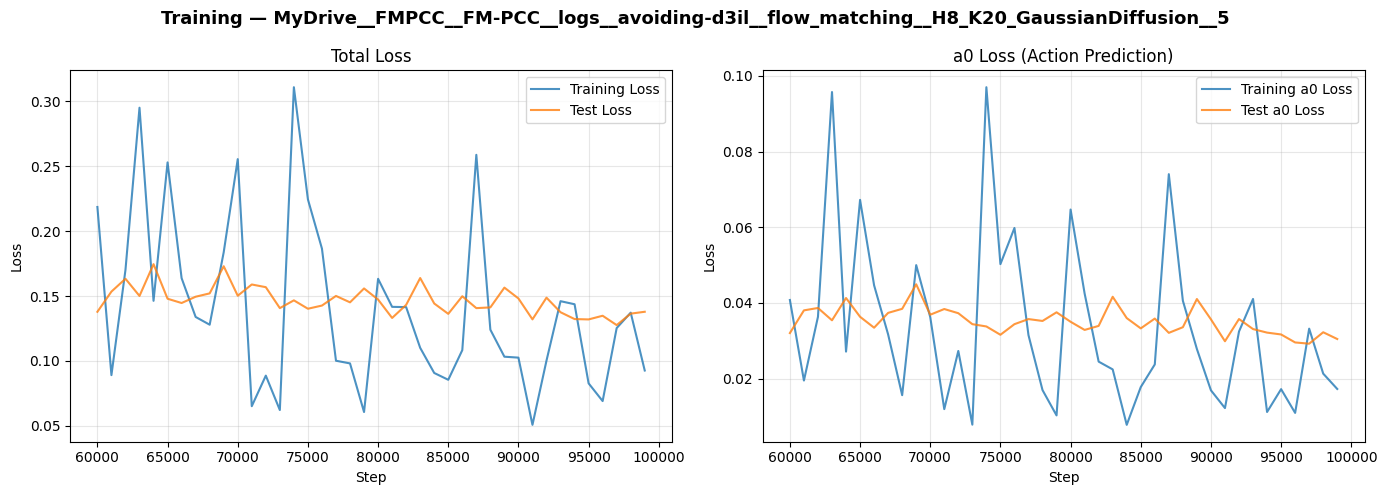


✅ Loss curves saved to /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5/MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__flow_matching__H8_K20_GaussianDiffusion__5__loss_curves.png
--------------------------------------------------------------------------------
============================== FILE: MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__flow_matching__H8_K20_GaussianDiffusion__5__loss_curves.png ==============================
--------------------------------------------------------------------------------


In [15]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── Fallback Unpickler ──
class FallbackUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if 'flow_matcher' in module:
            return type(name, (), {})
        return super().find_class(module, name)

# ── Target directory ──
target_dir = '/content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5'

path_parts = target_dir.rstrip('/').split('/')
identifier = '__'.join(path_parts[3:]).replace('Dmodels.diffusion.', '').replace('.', '_')
print(f"Run identifier: {identifier}\n")

all_files = [
    f for f in os.listdir(target_dir)
    if os.path.isfile(os.path.join(target_dir, f)) and ':' not in f
]

print(f"Found {len(all_files)} files in: {target_dir}\n")

for file_name in all_files:
    path = os.path.join(target_dir, file_name)
    print(f"{'='*30} FILE: {file_name} {'='*30}")

    try:
        # Handle NumPy Archive (.npz)
        if file_name.endswith('.npz'):
            with np.load(path, allow_pickle=True) as data:
                for key in data.files:
                    arr = data[key]
                    print(f"Key: {key:<20} | Shape: {str(arr.shape):<12} | Dtype: {arr.dtype}")
                    if arr.size > 0:
                        print(arr if arr.size < 10 else f"First 5: {arr.flatten()[:5]}...")

        # Handle Pickle Files (.pkl) — always use FallbackUnpickler
        elif file_name.endswith('.pkl'):
            with open(path, 'rb') as f:
                content = FallbackUnpickler(f).load()

            if isinstance(content, dict):
                for k, v in content.items():
                    print(f"{k:<25}: {v}")
            elif hasattr(content, '__dict__'):
                print(f"  Type: {type(content).__name__}")
                for k, v in vars(content).items():
                    print(f"  {k}: {v}")
            elif isinstance(content, (list, np.ndarray)):
                arr_content = np.array(content)
                print(f"Data Type: {type(content)} | Length: {len(arr_content)}")
                print(f"Last Values: {arr_content[-5:]}")
            else:
                print(content)

            # ── Plot loss curves if this is losses.pkl ──
            if file_name == 'losses.pkl' and isinstance(content, dict):
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                for key, label, color in [
                    ('training_losses', 'Training Loss', 'tab:blue'),
                    ('test_losses', 'Test Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[0].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[0].set_xlabel('Step')
                axes[0].set_ylabel('Loss')
                axes[0].set_title('Total Loss')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                for key, label, color in [
                    ('training_a0_losses', 'Training a0 Loss', 'tab:blue'),
                    ('test_a0_losses', 'Test a0 Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[1].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[1].set_xlabel('Step')
                axes[1].set_ylabel('Loss')
                axes[1].set_title('a0 Loss (Action Prediction)')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                plt.suptitle(f'Training — {identifier}', fontsize=13, fontweight='bold')
                plt.tight_layout()

                save_name = f'{identifier}__loss_curves.png'
                save_path = os.path.join(target_dir, save_name)
                plt.savefig(save_path, dpi=150)
                plt.show()
                print(f"\n✅ Loss curves saved to {save_path}")

        # Handle PyTorch Weights (.pt)
        elif file_name.endswith('.pt'):
            import torch
            checkpoint = torch.load(path, map_location='cpu')
            if isinstance(checkpoint, dict):
                print(f"Keys in Checkpoint: {list(checkpoint.keys())}")
            else:
                print("Raw Tensor/Object loaded.")

    except Exception as e:
        print(f"FAILED TO LOAD {file_name}: {e}")

    print("-" * 80)

Combined

Parsed 59 epoch lines from pasted text (steps 1999 → 60000)
  training_losses: added 58 points from console, total 98 points
  test_losses: added 58 points from console, total 98 points
  training_a0_losses: added 58 points from console, total 98 points
  test_a0_losses: added 58 points from console, total 98 points


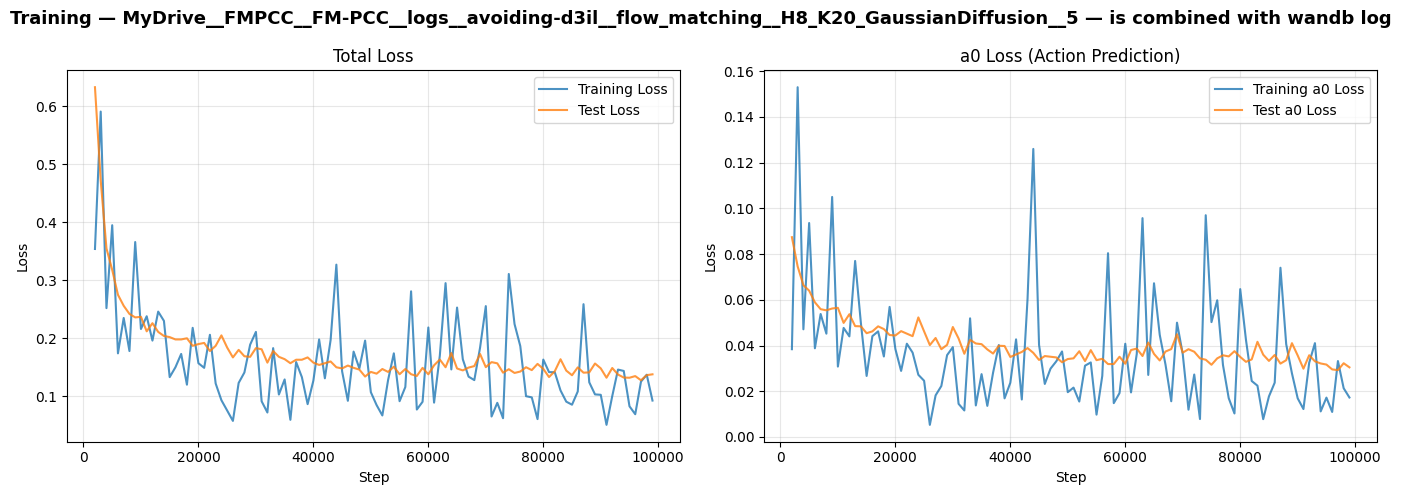


✅ Loss curves saved to /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5/MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__flow_matching__H8_K20_GaussianDiffusion__5__loss_curves__is_combined_with_wandb_log.png


In [25]:
import os, re, pickle
import numpy as np
import matplotlib.pyplot as plt

target_dir = "/content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/5"

class FallbackUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if "flow_matcher" in module:
            return type(name, (), {})
        return super().find_class(module, name)

def load_losses_pkl(path):
    with open(path, "rb") as f:
        d = FallbackUnpickler(f).load()
    out = {}
    for k, v in d.items():
        arr = np.array(v)
        if arr.ndim == 2 and arr.shape[1] == 2:
            out[k] = arr.astype(float)
    return out

pkl = load_losses_pkl(os.path.join(target_dir, "losses.pkl"))

# ---- Paste your full W&B console output here ----
WANDB_LOG_TEXT = r"""
Initial test loss:   1.0215, a0 loss:   0.1557
2026-03-28 11:52:57
Epoch 1: 100% 1000/1000 [01:20<00:00, 12.45it/s, a0_loss=0.0384, a0_loss_test=0.0874, diffusion_loss=0.708, loss=0.354, loss_test=0.633, lr=0.0001, step=1999]
2026-03-28 11:54:17
Epoch 2: 100% 1000/1000 [01:20<00:00, 12.36it/s, a0_loss=0.153, a0_loss_test=0.0746, diffusion_loss=1.18, loss=0.591, loss_test=0.472, lr=9.99e-5, step=2999]
2026-03-28 11:55:39
Epoch 3: 100% 1000/1000 [01:21<00:00, 12.32it/s, a0_loss=0.0471, a0_loss_test=0.0664, diffusion_loss=0.505, loss=0.252, loss_test=0.355, lr=9.98e-5, step=3999]
2026-03-28 11:57:00
Epoch 4: 100% 1000/1000 [01:20<00:00, 12.47it/s, a0_loss=0.0936, a0_loss_test=0.064, diffusion_loss=0.79, loss=0.395, loss_test=0.318, lr=9.96e-5, step=4999]
2026-03-28 11:58:20
Epoch 5: 100% 1000/1000 [01:20<00:00, 12.40it/s, a0_loss=0.0388, a0_loss_test=0.0589, diffusion_loss=0.349, loss=0.174, loss_test=0.275, lr=9.94e-5, step=5999]
2026-03-28 11:59:44
Epoch 6: 100% 1000/1000 [01:23<00:00, 11.92it/s, a0_loss=0.0538, a0_loss_test=0.0559, diffusion_loss=0.47, loss=0.235, loss_test=0.256, lr=9.91e-5, step=6999]
2026-03-28 12:01:06
Epoch 7: 100% 1000/1000 [01:21<00:00, 12.26it/s, a0_loss=0.0452, a0_loss_test=0.0554, diffusion_loss=0.357, loss=0.178, loss_test=0.242, lr=9.88e-5, step=7999]
2026-03-28 12:02:35
Epoch 8: 100% 1000/1000 [01:28<00:00, 11.28it/s, a0_loss=0.105, a0_loss_test=0.0562, diffusion_loss=0.733, loss=0.366, loss_test=0.236, lr=9.84e-5, step=8999]
2026-03-28 12:03:55
Epoch 9: 100% 1000/1000 [01:19<00:00, 12.51it/s, a0_loss=0.0308, a0_loss_test=0.0565, diffusion_loss=0.433, loss=0.216, loss_test=0.237, lr=9.8e-5, step=9999]
2026-03-28 12:05:15
Epoch 10: 100% 1000/1000 [01:21<00:00, 12.28it/s, a0_loss=0.0477, a0_loss_test=0.0499, diffusion_loss=0.477, loss=0.238, loss_test=0.212, lr=9.75e-5, step=10999]
2026-03-28 12:06:37
Epoch 11: 100% 1000/1000 [01:20<00:00, 12.42it/s, a0_loss=0.044, a0_loss_test=0.0537, diffusion_loss=0.392, loss=0.196, loss_test=0.226, lr=9.7e-5, step=11999]
2026-03-28 12:07:55
Epoch 12: 100% 1000/1000 [01:19<00:00, 12.50it/s, a0_loss=0.077, a0_loss_test=0.0485, diffusion_loss=0.492, loss=0.246, loss_test=0.211, lr=9.64e-5, step=12999]
2026-03-28 12:09:18
Epoch 13: 100% 1000/1000 [01:21<00:00, 12.27it/s, a0_loss=0.0499, a0_loss_test=0.0484, diffusion_loss=0.461, loss=0.23, loss_test=0.204, lr=9.58e-5, step=13999]
2026-03-28 12:10:38
Epoch 14: 100% 1000/1000 [01:20<00:00, 12.35it/s, a0_loss=0.0267, a0_loss_test=0.0454, diffusion_loss=0.265, loss=0.133, loss_test=0.202, lr=9.51e-5, step=14999]
2026-03-28 12:12:02
Epoch 15: 100% 1000/1000 [01:23<00:00, 11.98it/s, a0_loss=0.0441, a0_loss_test=0.0462, diffusion_loss=0.3, loss=0.15, loss_test=0.198, lr=9.44e-5, step=15999]
2026-03-28 12:13:24
Epoch 16: 100% 1000/1000 [01:22<00:00, 12.06it/s, a0_loss=0.0462, a0_loss_test=0.0484, diffusion_loss=0.345, loss=0.173, loss_test=0.198, lr=9.37e-5, step=16999]
2026-03-28 12:14:46
Epoch 17: 100% 1000/1000 [01:20<00:00, 12.39it/s, a0_loss=0.0352, a0_loss_test=0.0472, diffusion_loss=0.239, loss=0.12, loss_test=0.2, lr=9.29e-5, step=17999]
2026-03-28 12:16:07
Epoch 18: 100% 1000/1000 [01:21<00:00, 12.31it/s, a0_loss=0.0569, a0_loss_test=0.0446, diffusion_loss=0.435, loss=0.218, loss_test=0.187, lr=9.21e-5, step=18999]
2026-03-28 12:17:29
Epoch 19: 100% 1000/1000 [01:21<00:00, 12.31it/s, a0_loss=0.0385, a0_loss_test=0.0444, diffusion_loss=0.313, loss=0.157, loss_test=0.19, lr=9.12e-5, step=2e+4]
2026-03-28 12:18:49
Epoch 20: 100% 1000/1000 [01:20<00:00, 12.47it/s, a0_loss=0.0289, a0_loss_test=0.0463, diffusion_loss=0.298, loss=0.149, loss_test=0.192, lr=9.03e-5, step=20999]
2026-03-28 12:20:11
Epoch 21: 100% 1000/1000 [01:22<00:00, 12.14it/s, a0_loss=0.0408, a0_loss_test=0.0452, diffusion_loss=0.411, loss=0.206, loss_test=0.178, lr=8.93e-5, step=21999]
2026-03-28 12:21:31
Epoch 22: 100% 1000/1000 [01:21<00:00, 12.33it/s, a0_loss=0.0369, a0_loss_test=0.0441, diffusion_loss=0.245, loss=0.122, loss_test=0.187, lr=8.83e-5, step=22999]
2026-03-28 12:22:52
Epoch 23: 100% 1000/1000 [01:20<00:00, 12.46it/s, a0_loss=0.0272, a0_loss_test=0.0523, diffusion_loss=0.186, loss=0.0932, loss_test=0.205, lr=8.73e-5, step=23999]
2026-03-28 12:24:14
Epoch 24: 100% 1000/1000 [01:20<00:00, 12.37it/s, a0_loss=0.0246, a0_loss_test=0.0462, diffusion_loss=0.151, loss=0.0754, loss_test=0.184, lr=8.62e-5, step=24999]
2026-03-28 12:25:36
Epoch 25: 100% 1000/1000 [01:22<00:00, 12.05it/s, a0_loss=0.00531, a0_loss_test=0.0402, diffusion_loss=0.115, loss=0.0575, loss_test=0.167, lr=8.51e-5, step=25999]
2026-03-28 12:26:56
Epoch 26: 100% 1000/1000 [01:20<00:00, 12.43it/s, a0_loss=0.0182, a0_loss_test=0.0433, diffusion_loss=0.246, loss=0.123, loss_test=0.18, lr=8.39e-5, step=26999]
2026-03-28 12:28:16
Epoch 27: 100% 1000/1000 [01:21<00:00, 12.33it/s, a0_loss=0.0223, a0_loss_test=0.0384, diffusion_loss=0.283, loss=0.141, loss_test=0.169, lr=8.27e-5, step=27999]
2026-03-28 12:29:37
Epoch 28: 100% 1000/1000 [01:18<00:00, 12.66it/s, a0_loss=0.0358, a0_loss_test=0.0403, diffusion_loss=0.378, loss=0.189, loss_test=0.168, lr=8.15e-5, step=28999]
2026-03-28 12:30:55
Epoch 29: 100% 1000/1000 [01:18<00:00, 12.74it/s, a0_loss=0.0393, a0_loss_test=0.0481, diffusion_loss=0.423, loss=0.211, loss_test=0.183, lr=8.03e-5, step=3e+4]
2026-03-28 12:32:15
Epoch 30: 100% 1000/1000 [01:19<00:00, 12.57it/s, a0_loss=0.0145, a0_loss_test=0.0431, diffusion_loss=0.183, loss=0.0913, loss_test=0.181, lr=7.9e-5, step=30999]
2026-03-28 12:33:37
Epoch 31: 100% 1000/1000 [01:21<00:00, 12.21it/s, a0_loss=0.0116, a0_loss_test=0.0364, diffusion_loss=0.144, loss=0.072, loss_test=0.158, lr=7.77e-5, step=31999]
2026-03-28 12:34:57
Epoch 32: 100% 1000/1000 [01:21<00:00, 12.21it/s, a0_loss=0.0519, a0_loss_test=0.0425, diffusion_loss=0.366, loss=0.183, loss_test=0.178, lr=7.64e-5, step=32999]
2026-03-28 12:36:20
Epoch 33: 100% 1000/1000 [01:20<00:00, 12.35it/s, a0_loss=0.0138, a0_loss_test=0.0409, diffusion_loss=0.205, loss=0.103, loss_test=0.168, lr=7.5e-5, step=33999]
2026-03-28 12:37:40
Epoch 34: 100% 1000/1000 [01:21<00:00, 12.23it/s, a0_loss=0.0275, a0_loss_test=0.0406, diffusion_loss=0.258, loss=0.129, loss_test=0.164, lr=7.36e-5, step=34999]
2026-03-28 12:39:04
Epoch 35: 100% 1000/1000 [01:22<00:00, 12.17it/s, a0_loss=0.0136, a0_loss_test=0.0383, diffusion_loss=0.119, loss=0.0594, loss_test=0.157, lr=7.22e-5, step=35999]
2026-03-28 12:40:24
Epoch 36: 100% 1000/1000 [01:20<00:00, 12.47it/s, a0_loss=0.0281, a0_loss_test=0.0365, diffusion_loss=0.319, loss=0.159, loss_test=0.163, lr=7.08e-5, step=36999]
2026-03-28 12:41:42
Epoch 37: 100% 1000/1000 [01:19<00:00, 12.56it/s, a0_loss=0.0402, a0_loss_test=0.0399, diffusion_loss=0.266, loss=0.133, loss_test=0.163, lr=6.93e-5, step=37999]
2026-03-28 12:43:03
Epoch 38: 100% 1000/1000 [01:19<00:00, 12.65it/s, a0_loss=0.0169, a0_loss_test=0.0398, diffusion_loss=0.173, loss=0.0864, loss_test=0.167, lr=6.78e-5, step=38999]
2026-03-28 12:44:23
Epoch 39: 100% 1000/1000 [01:20<00:00, 12.47it/s, a0_loss=0.0237, a0_loss_test=0.035, diffusion_loss=0.254, loss=0.127, loss_test=0.158, lr=6.64e-5, step=4e+4]
2026-03-28 12:45:45
Epoch 40: 100% 1000/1000 [01:23<00:00, 12.04it/s, a0_loss=0.0427, a0_loss_test=0.0361, diffusion_loss=0.396, loss=0.198, loss_test=0.154, lr=6.48e-5, step=40999]
2026-03-28 12:47:05
Epoch 41: 100% 1000/1000 [01:19<00:00, 12.58it/s, a0_loss=0.0164, a0_loss_test=0.0372, diffusion_loss=0.263, loss=0.131, loss_test=0.157, lr=6.33e-5, step=41999]
2026-03-28 12:48:25
Epoch 42: 100% 1000/1000 [01:20<00:00, 12.41it/s, a0_loss=0.0605, a0_loss_test=0.0389, diffusion_loss=0.394, loss=0.197, loss_test=0.16, lr=6.18e-5, step=42999]
2026-03-28 12:49:46
Epoch 43: 100% 1000/1000 [01:21<00:00, 12.33it/s, a0_loss=0.126, a0_loss_test=0.0368, diffusion_loss=0.654, loss=0.327, loss_test=0.15, lr=6.02e-5, step=43999]
2026-03-28 12:51:08
Epoch 44: 100% 1000/1000 [01:22<00:00, 12.17it/s, a0_loss=0.0403, a0_loss_test=0.0337, diffusion_loss=0.285, loss=0.143, loss_test=0.148, lr=5.87e-5, step=44999]
2026-03-28 12:52:30
Epoch 45: 100% 1000/1000 [01:22<00:00, 12.18it/s, a0_loss=0.0232, a0_loss_test=0.0354, diffusion_loss=0.184, loss=0.0922, loss_test=0.153, lr=5.71e-5, step=45999]
2026-03-28 12:53:50
Epoch 46: 100% 1000/1000 [01:20<00:00, 12.44it/s, a0_loss=0.0299, a0_loss_test=0.0351, diffusion_loss=0.354, loss=0.177, loss_test=0.149, lr=5.55e-5, step=46999]
2026-03-28 12:55:11
Epoch 47: 100% 1000/1000 [01:20<00:00, 12.45it/s, a0_loss=0.0331, a0_loss_test=0.0348, diffusion_loss=0.296, loss=0.148, loss_test=0.146, lr=5.4e-5, step=47999]
2026-03-28 12:56:31
Epoch 48: 100% 1000/1000 [01:20<00:00, 12.43it/s, a0_loss=0.0374, a0_loss_test=0.0327, diffusion_loss=0.391, loss=0.196, loss_test=0.134, lr=5.24e-5, step=48999]
2026-03-28 12:57:51
Epoch 49: 100% 1000/1000 [01:19<00:00, 12.56it/s, a0_loss=0.0196, a0_loss_test=0.0341, diffusion_loss=0.215, loss=0.107, loss_test=0.142, lr=5.08e-5, step=5e+4]
2026-03-28 12:59:11
Epoch 50: 100% 1000/1000 [01:19<00:00, 12.53it/s, a0_loss=0.0216, a0_loss_test=0.0344, diffusion_loss=0.17, loss=0.0848, loss_test=0.139, lr=4.92e-5, step=50999]
2026-03-28 13:00:31
Epoch 51: 100% 1000/1000 [01:19<00:00, 12.62it/s, a0_loss=0.0155, a0_loss_test=0.0375, diffusion_loss=0.134, loss=0.0669, loss_test=0.147, lr=4.76e-5, step=51999]
2026-03-28 13:01:51
Epoch 52: 100% 1000/1000 [01:20<00:00, 12.36it/s, a0_loss=0.0312, a0_loss_test=0.0332, diffusion_loss=0.256, loss=0.128, loss_test=0.142, lr=4.6e-5, step=52999]
2026-03-28 13:03:14
Epoch 53: 100% 1000/1000 [01:21<00:00, 12.23it/s, a0_loss=0.0326, a0_loss_test=0.038, diffusion_loss=0.349, loss=0.174, loss_test=0.151, lr=4.45e-5, step=53999]
2026-03-28 13:04:32
Epoch 54: 100% 1000/1000 [01:19<00:00, 12.59it/s, a0_loss=0.00978, a0_loss_test=0.0336, diffusion_loss=0.183, loss=0.0915, loss_test=0.138, lr=4.29e-5, step=54999]
2026-03-28 13:05:52
Epoch 55: 100% 1000/1000 [01:19<00:00, 12.57it/s, a0_loss=0.0267, a0_loss_test=0.0342, diffusion_loss=0.232, loss=0.116, loss_test=0.147, lr=4.13e-5, step=55999]
2026-03-28 13:07:12
Epoch 56: 100% 1000/1000 [01:20<00:00, 12.49it/s, a0_loss=0.0804, a0_loss_test=0.0319, diffusion_loss=0.562, loss=0.281, loss_test=0.138, lr=3.98e-5, step=56999]
2026-03-28 13:08:32
Epoch 57: 100% 1000/1000 [01:20<00:00, 12.39it/s, a0_loss=0.0148, a0_loss_test=0.0319, diffusion_loss=0.154, loss=0.0771, loss_test=0.135, lr=3.82e-5, step=57999]
2026-03-28 13:09:53
Epoch 58: 100% 1000/1000 [01:19<00:00, 12.59it/s, a0_loss=0.0192, a0_loss_test=0.0351, diffusion_loss=0.181, loss=0.0905, loss_test=0.149, lr=3.67e-5, step=58999]
2026-03-28 13:11:13
Epoch 59: 100% 1000/1000 [01:20<00:00, 12.42it/s, a0_loss=0.0501, a0_loss_test=0.0306, diffusion_loss=0.354, loss=0.177, loss_test=0.129, lr=3.52e-5, step=6e+4]
2026-03-28 13:12:31
""".strip()

# ---- Parse ----
def parse_console(text):
    text = re.sub(r"(?=\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})", "\n", text)
    rows = []
    for line in text.splitlines():
        if "Epoch" not in line or "step=" not in line:
            continue
        def grab(pat):
            m = re.search(pat, line)
            return float(m.group(1)) if m else np.nan
        step = grab(r"step=([0-9]+(?:\.[0-9]+)?(?:e\+?[0-9]+)?)")
        if np.isnan(step):
            continue
        step = int(step)
        rows.append((
            step,
            grab(r"(?<!\w)loss=([0-9]+(?:\.[0-9]+)?(?:e[+-]?[0-9]+)?)"),
            grab(r"(?<!\w)loss_test=([0-9]+(?:\.[0-9]+)?(?:e[+-]?[0-9]+)?)"),
            grab(r"(?<!\w)a0_loss=([0-9]+(?:\.[0-9]+)?(?:e[+-]?[0-9]+)?)"),
            grab(r"a0_loss_test=([0-9]+(?:\.[0-9]+)?(?:e[+-]?[0-9]+)?)"),
        ))
    if not rows:
        raise ValueError("No rows parsed.")
    return np.array(sorted(rows, key=lambda x: x[0]), dtype=float)

w = parse_console(WANDB_LOG_TEXT)
print(f"Parsed {len(w)} epoch lines from pasted text (steps {int(w[0,0])} → {int(w[-1,0])})")

# ---- Combine: only add steps NOT already in pkl ----
def combine(local_arr, extra_steps, extra_vals):
    local_steps = local_arr[:, 0].astype(int)
    local_vals  = local_arr[:, 1].astype(float)
    local_set = set(local_steps.tolist())
    fin = np.isfinite(extra_vals)
    keep = np.array([s not in local_set for s in extra_steps]) & fin
    all_s = np.concatenate([extra_steps[keep], local_steps])
    all_v = np.concatenate([extra_vals[keep],  local_vals])
    order = np.argsort(all_s)
    return np.c_[all_s[order], all_v[order]], int(keep.sum())

# mapping: pkl key → column index in parsed array
SPECS = [
    ("training_losses",    1),
    ("test_losses",        2),
    ("training_a0_losses", 3),
    ("test_a0_losses",     4),
]

combined = {}
for pkl_key, col in SPECS:
    combined[pkl_key], added = combine(pkl[pkl_key], w[:,0].astype(int), w[:,col])
    print(f"  {pkl_key}: added {added} points from console, total {len(combined[pkl_key])} points")

# ---- Plot: 2 subplots, each with 2 curves (train + test) ----
path_parts = target_dir.rstrip("/").split("/")
identifier = "__".join(path_parts[3:]).replace("Dmodels.diffusion.", "").replace(".", "_")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Total Loss
for key, label, color in [
    ("training_losses", "Training Loss", "tab:blue"),
    ("test_losses",     "Test Loss",     "tab:orange"),
]:
    data = combined[key]
    axes[0].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Total Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: a0 Loss
for key, label, color in [
    ("training_a0_losses", "Training a0 Loss", "tab:blue"),
    ("test_a0_losses",     "Test a0 Loss",     "tab:orange"),
]:
    data = combined[key]
    axes[1].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].set_title("a0 Loss (Action Prediction)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Training — {identifier} — is combined with wandb log", fontsize=13, fontweight="bold")
plt.tight_layout()

save_name = f"{identifier}__loss_curves__is_combined_with_wandb_log.png"
save_path = os.path.join(target_dir, save_name)
plt.savefig(save_path, dpi=150)
plt.show()
print(f"\n✅ Loss curves saved to {save_path}")

FM - 6

Full

Run identifier: MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__flow_matching__H8_K20_GaussianDiffusion__6

Found 12 files in: /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/6

============================== FILE: dataset_config.pkl ==============================
  Type: Config
  _class: <class '__main__.SequenceDataset'>
  _device: None
  _dict: {'env': 'avoiding-d3il', 'horizon': 8, 'normalizer': 'LimitsNormalizer', 'preprocess_fns': [], 'use_padding': True, 'max_path_length': 150, 'include_returns': True, 'returns_scale': 150, 'discount': 0.99}
--------------------------------------------------------------------------------
============================== FILE: model_config.pkl ==============================
  Type: Config
  _class: <class '__main__.UNet1DTemporalCondModel'>
  _device: cuda
  _dict: {'horizon': 8, 'transition_dim': 6, 'cond_dim': 4, 'dim_mults': (1, 2, 4, 8), 'returns_condition': False, 'dim': 32, 'conditi

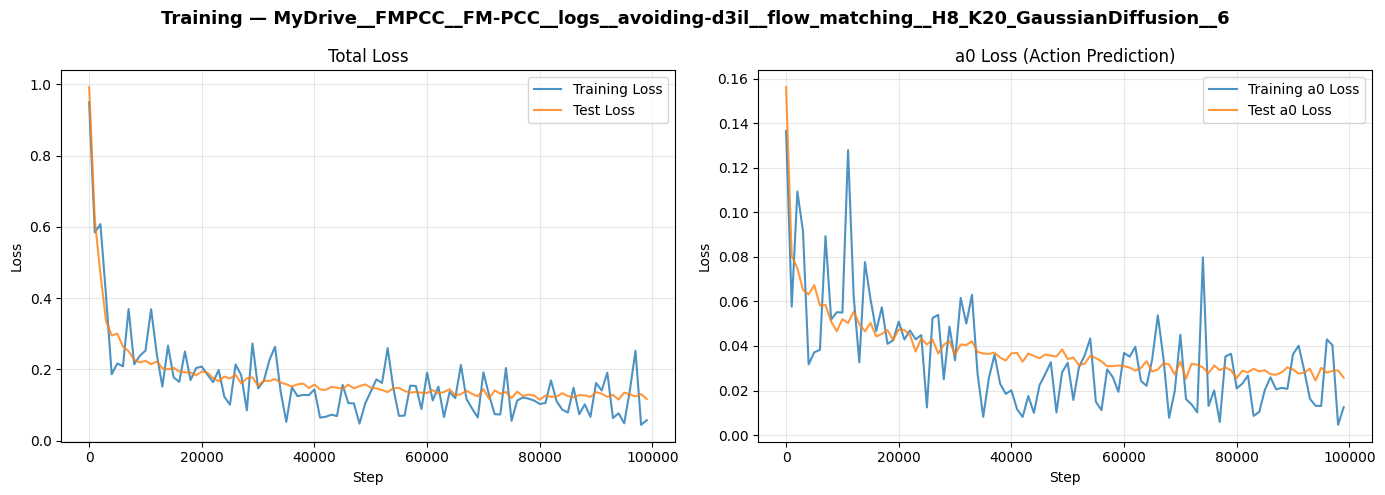


✅ Loss curves saved to /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/6/MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__flow_matching__H8_K20_GaussianDiffusion__6__loss_curves.png
--------------------------------------------------------------------------------
============================== FILE: MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__flow_matching__H8_K20_GaussianDiffusion__6__loss_curves.png ==============================
--------------------------------------------------------------------------------


In [14]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── Fallback Unpickler ──
class FallbackUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if 'flow_matcher' in module:
            return type(name, (), {})
        return super().find_class(module, name)

# ── Target directory ──
target_dir = '/content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/6'

path_parts = target_dir.rstrip('/').split('/')
identifier = '__'.join(path_parts[3:]).replace('Dmodels.diffusion.', '').replace('.', '_')
print(f"Run identifier: {identifier}\n")

all_files = [
    f for f in os.listdir(target_dir)
    if os.path.isfile(os.path.join(target_dir, f)) and ':' not in f
]

print(f"Found {len(all_files)} files in: {target_dir}\n")

for file_name in all_files:
    path = os.path.join(target_dir, file_name)
    print(f"{'='*30} FILE: {file_name} {'='*30}")

    try:
        # Handle NumPy Archive (.npz)
        if file_name.endswith('.npz'):
            with np.load(path, allow_pickle=True) as data:
                for key in data.files:
                    arr = data[key]
                    print(f"Key: {key:<20} | Shape: {str(arr.shape):<12} | Dtype: {arr.dtype}")
                    if arr.size > 0:
                        print(arr if arr.size < 10 else f"First 5: {arr.flatten()[:5]}...")

        # Handle Pickle Files (.pkl) — always use FallbackUnpickler
        elif file_name.endswith('.pkl'):
            with open(path, 'rb') as f:
                content = FallbackUnpickler(f).load()

            if isinstance(content, dict):
                for k, v in content.items():
                    print(f"{k:<25}: {v}")
            elif hasattr(content, '__dict__'):
                print(f"  Type: {type(content).__name__}")
                for k, v in vars(content).items():
                    print(f"  {k}: {v}")
            elif isinstance(content, (list, np.ndarray)):
                arr_content = np.array(content)
                print(f"Data Type: {type(content)} | Length: {len(arr_content)}")
                print(f"Last Values: {arr_content[-5:]}")
            else:
                print(content)

            # ── Plot loss curves if this is losses.pkl ──
            if file_name == 'losses.pkl' and isinstance(content, dict):
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                for key, label, color in [
                    ('training_losses', 'Training Loss', 'tab:blue'),
                    ('test_losses', 'Test Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[0].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[0].set_xlabel('Step')
                axes[0].set_ylabel('Loss')
                axes[0].set_title('Total Loss')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                for key, label, color in [
                    ('training_a0_losses', 'Training a0 Loss', 'tab:blue'),
                    ('test_a0_losses', 'Test a0 Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[1].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[1].set_xlabel('Step')
                axes[1].set_ylabel('Loss')
                axes[1].set_title('a0 Loss (Action Prediction)')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                plt.suptitle(f'Training — {identifier}', fontsize=13, fontweight='bold')
                plt.tight_layout()

                save_name = f'{identifier}__loss_curves.png'
                save_path = os.path.join(target_dir, save_name)
                plt.savefig(save_path, dpi=150)
                plt.show()
                print(f"\n✅ Loss curves saved to {save_path}")

        # Handle PyTorch Weights (.pt)
        elif file_name.endswith('.pt'):
            import torch
            checkpoint = torch.load(path, map_location='cpu')
            if isinstance(checkpoint, dict):
                print(f"Keys in Checkpoint: {list(checkpoint.keys())}")
            else:
                print("Raw Tensor/Object loaded.")

    except Exception as e:
        print(f"FAILED TO LOAD {file_name}: {e}")

    print("-" * 80)

DPCC - 5

Full

Run identifier: MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__diffusion__H8_K20_Dmodels_GaussianDiffusion__5

Found 16 files in: /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/5

============================== FILE: state_0.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: state_2.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: state_4.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: state_6.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------

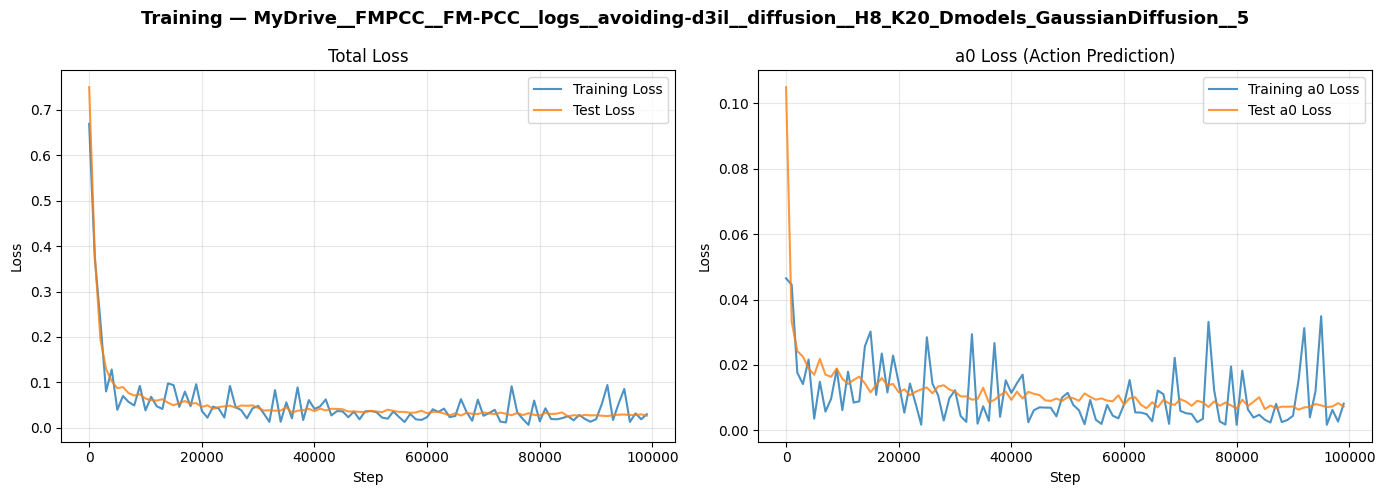


✅ Loss curves saved to /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/5/MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__diffusion__H8_K20_Dmodels_GaussianDiffusion__5__loss_curves.png
--------------------------------------------------------------------------------
============================== FILE: MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__diffusion__H8_K20_Dmodels_GaussianDiffusion__5__loss_curves.png ==============================
--------------------------------------------------------------------------------


In [12]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── Fallback Unpickler ──
class FallbackUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if 'flow_matcher' in module:
            return type(name, (), {})
        return super().find_class(module, name)

# ── Target directory ──
target_dir = '/content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/5'

path_parts = target_dir.rstrip('/').split('/')
identifier = '__'.join(path_parts[3:]).replace('Dmodels.diffusion.', '').replace('.', '_')
print(f"Run identifier: {identifier}\n")

all_files = [
    f for f in os.listdir(target_dir)
    if os.path.isfile(os.path.join(target_dir, f)) and ':' not in f
]

print(f"Found {len(all_files)} files in: {target_dir}\n")

for file_name in all_files:
    path = os.path.join(target_dir, file_name)
    print(f"{'='*30} FILE: {file_name} {'='*30}")

    try:
        # Handle NumPy Archive (.npz)
        if file_name.endswith('.npz'):
            with np.load(path, allow_pickle=True) as data:
                for key in data.files:
                    arr = data[key]
                    print(f"Key: {key:<20} | Shape: {str(arr.shape):<12} | Dtype: {arr.dtype}")
                    if arr.size > 0:
                        print(arr if arr.size < 10 else f"First 5: {arr.flatten()[:5]}...")

        # Handle Pickle Files (.pkl) — always use FallbackUnpickler
        elif file_name.endswith('.pkl'):
            with open(path, 'rb') as f:
                content = FallbackUnpickler(f).load()

            if isinstance(content, dict):
                for k, v in content.items():
                    print(f"{k:<25}: {v}")
            elif hasattr(content, '__dict__'):
                print(f"  Type: {type(content).__name__}")
                for k, v in vars(content).items():
                    print(f"  {k}: {v}")
            elif isinstance(content, (list, np.ndarray)):
                arr_content = np.array(content)
                print(f"Data Type: {type(content)} | Length: {len(arr_content)}")
                print(f"Last Values: {arr_content[-5:]}")
            else:
                print(content)

            # ── Plot loss curves if this is losses.pkl ──
            if file_name == 'losses.pkl' and isinstance(content, dict):
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                for key, label, color in [
                    ('training_losses', 'Training Loss', 'tab:blue'),
                    ('test_losses', 'Test Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[0].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[0].set_xlabel('Step')
                axes[0].set_ylabel('Loss')
                axes[0].set_title('Total Loss')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                for key, label, color in [
                    ('training_a0_losses', 'Training a0 Loss', 'tab:blue'),
                    ('test_a0_losses', 'Test a0 Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[1].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[1].set_xlabel('Step')
                axes[1].set_ylabel('Loss')
                axes[1].set_title('a0 Loss (Action Prediction)')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                plt.suptitle(f'Training — {identifier}', fontsize=13, fontweight='bold')
                plt.tight_layout()

                save_name = f'{identifier}__loss_curves.png'
                save_path = os.path.join(target_dir, save_name)
                plt.savefig(save_path, dpi=150)
                plt.show()
                print(f"\n✅ Loss curves saved to {save_path}")

        # Handle PyTorch Weights (.pt)
        elif file_name.endswith('.pt'):
            import torch
            checkpoint = torch.load(path, map_location='cpu')
            if isinstance(checkpoint, dict):
                print(f"Keys in Checkpoint: {list(checkpoint.keys())}")
            else:
                print("Raw Tensor/Object loaded.")

    except Exception as e:
        print(f"FAILED TO LOAD {file_name}: {e}")

    print("-" * 80)

DPCC - 6

Part

from Wandb

```
2026-03-20 15:47:31
[utils/config ] Config: <class 'diffuser.datasets.sequence.SequenceDataset'>
2026-03-20 15:47:31
    discount: 0.99
2026-03-20 15:47:31
    env: avoiding-d3il
2026-03-20 15:47:31
    horizon: 8
2026-03-20 15:47:31
    include_returns: True
2026-03-20 15:47:31
    max_path_length: 150
2026-03-20 15:47:31
    normalizer: LimitsNormalizer
2026-03-20 15:47:31
    preprocess_fns: []
2026-03-20 15:47:31
    returns_scale: 150
2026-03-20 15:47:31
    use_padding: True
2026-03-20 15:47:31
[ utils/config ] Saved config to: logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6/dataset_config.pkl
2026-03-20 15:47:31
[ datasets/buffer ] Fields:
2026-03-20 15:47:31
    observations: (96, 150, 4)
2026-03-20 15:47:31
    actions: (96, 150, 2)
2026-03-20 15:47:31
    rewards: (96, 150, 1)
2026-03-20 15:47:31
    terminals: (96, 150, 1)
2026-03-20 15:47:31
    normed_observations: (96, 150, 4)
2026-03-20 15:47:31
    normed_actions: (96, 150, 2)
2026-03-20 15:47:33
[utils/config ] Config: <class 'diffuser.models.unet1d_temporal_cond.UNet1DTemporalCondModel'>
2026-03-20 15:47:33
    cond_dim: 4
2026-03-20 15:47:33
    condition_dropout: 0.25
2026-03-20 15:47:33
    dim: 32
2026-03-20 15:47:33
    dim_mults: (1, 2, 4, 8)
2026-03-20 15:47:33
    horizon: 8
2026-03-20 15:47:33
    returns_condition: False
2026-03-20 15:47:33
    transition_dim: 6
2026-03-20 15:47:33
[ utils/config ] Saved config to: logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6/model_config.pkl
2026-03-20 15:47:33
[utils/config ] Config: <class 'diffuser.models.diffusion.GaussianDiffusion'>
2026-03-20 15:47:33
    action_dim: 2
2026-03-20 15:47:33
    action_weight: 10
2026-03-20 15:47:33
    clip_denoised: False
2026-03-20 15:47:33
    condition_guidance_w: 1.2
2026-03-20 15:47:33
    goal_dim: 0
2026-03-20 15:47:33
    horizon: 8
2026-03-20 15:47:33
    loss_discount: 1.0
2026-03-20 15:47:33
    loss_type: l2
2026-03-20 15:47:33
    n_timesteps: 20
2026-03-20 15:47:33
    observation_dim: 4
2026-03-20 15:47:33
    predict_epsilon: True
2026-03-20 15:47:33
    returns_condition: False
2026-03-20 15:47:33
[ utils/config ] Saved config to: logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6/diffusion_config.pkl
2026-03-20 15:47:33
[utils/config ] Config: <class 'diffuser.utils.training.Trainer'>
2026-03-20 15:47:33
    ema_decay: 0.995
2026-03-20 15:47:33
    gradient_accumulate_every: 2
2026-03-20 15:47:33
    n_steps_per_epoch: 1000
2026-03-20 15:47:33
    n_train_steps: 100000.0
2026-03-20 15:47:33
    results_folder: logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6
2026-03-20 15:47:33
    train_batch_size: 8
2026-03-20 15:47:33
    train_lr: 0.0001
2026-03-20 15:47:33
    train_test_split: 0.9
2026-03-20 15:47:33
[ utils/config ] Saved config to: logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6/trainer_config.pkl
2026-03-20 15:48:53
Epoch 0: 100% 1000/1000 [01:21<00:00, 12.31it/s, a0_loss=0.0414, a0_loss_test=0.112, diffusion_loss=0.853, loss=0.426, loss_test=0.751, lr=0.0001, step=999]
2026-03-20 15:47:35
Initial test loss:   0.7509, a0 loss:   0.1115
2026-03-20 15:50:14
Epoch 1: 100% 1000/1000 [01:19<00:00, 12.57it/s, a0_loss=0.0371, a0_loss_test=0.0343, diffusion_loss=0.483, loss=0.241, loss_test=0.393, lr=0.0001, step=1999]
2026-03-20 15:51:34
Epoch 2: 100% 1000/1000 [01:20<00:00, 12.44it/s, a0_loss=0.0183, a0_loss_test=0.0256, diffusion_loss=0.195, loss=0.0975, loss_test=0.196, lr=9.99e-5, step=2999]
2026-03-20 15:52:56
Epoch 3: 100% 1000/1000 [01:21<00:00, 12.26it/s, a0_loss=0.0145, a0_loss_test=0.0219, diffusion_loss=0.157, loss=0.0783, loss_test=0.134, lr=9.98e-5, step=3999]
2026-03-20 15:54:20
Epoch 4: 100% 1000/1000 [01:25<00:00, 11.65it/s, a0_loss=0.0109, a0_loss_test=0.0212, diffusion_loss=0.142, loss=0.0712, loss_test=0.105, lr=9.96e-5, step=4999]
2026-03-20 15:55:45
Epoch 5: 100% 1000/1000 [01:23<00:00, 12.00it/s, a0_loss=0.0195, a0_loss_test=0.0219, diffusion_loss=0.199, loss=0.0993, loss_test=0.0995, lr=9.94e-5, step=5999]
2026-03-20 15:57:05
Epoch 6: 100% 1000/1000 [01:21<00:00, 12.32it/s, a0_loss=0.00851, a0_loss_test=0.0197, diffusion_loss=0.0818, loss=0.0409, loss_test=0.0904, lr=9.91e-5, step=6999]
2026-03-20 15:58:29
Epoch 7: 100% 1000/1000 [01:23<00:00, 12.05it/s, a0_loss=0.0373, a0_loss_test=0.0188, diffusion_loss=0.323, loss=0.161, loss_test=0.0845, lr=9.88e-5, step=7999]
2026-03-20 15:59:49
Epoch 8: 100% 1000/1000 [01:21<00:00, 12.28it/s, a0_loss=0.0197, a0_loss_test=0.0189, diffusion_loss=0.133, loss=0.0664, loss_test=0.0811, lr=9.84e-5, step=8999]
2026-03-20 16:01:11
Epoch 9: 100% 1000/1000 [01:20<00:00, 12.39it/s, a0_loss=0.0206, a0_loss_test=0.0155, diffusion_loss=0.228, loss=0.114, loss_test=0.0666, lr=9.8e-5, step=9999]
2026-03-20 16:02:32
Epoch 10: 100% 1000/1000 [01:21<00:00, 12.32it/s, a0_loss=0.00351, a0_loss_test=0.014, diffusion_loss=0.0464, loss=0.0232, loss_test=0.0603, lr=9.75e-5, step=10999]
2026-03-20 16:03:50
Epoch 11: 100% 1000/1000 [01:19<00:00, 12.65it/s, a0_loss=0.0101, a0_loss_test=0.0152, diffusion_loss=0.0833, loss=0.0416, loss_test=0.0617, lr=9.7e-5, step=11999]
2026-03-20 16:05:12
Epoch 12: 100% 1000/1000 [01:21<00:00, 12.25it/s, a0_loss=0.048, a0_loss_test=0.0155, diffusion_loss=0.41, loss=0.205, loss_test=0.0623, lr=9.64e-5, step=12999]
2026-03-20 16:06:34
Epoch 13: 100% 1000/1000 [01:21<00:00, 12.28it/s, a0_loss=0.0183, a0_loss_test=0.0147, diffusion_loss=0.123, loss=0.0613, loss_test=0.0576, lr=9.58e-5, step=13999]
2026-03-20 16:07:56
Epoch 14: 100% 1000/1000 [01:21<00:00, 12.20it/s, a0_loss=0.0175, a0_loss_test=0.0134, diffusion_loss=0.0995, loss=0.0498, loss_test=0.0547, lr=9.51e-5, step=14999]
2026-03-20 16:09:17
Epoch 15: 100% 1000/1000 [01:21<00:00, 12.34it/s, a0_loss=0.0108, a0_loss_test=0.015, diffusion_loss=0.152, loss=0.0758, loss_test=0.0599, lr=9.44e-5, step=15999]
2026-03-20 16:10:39
Epoch 16: 100% 1000/1000 [01:21<00:00, 12.32it/s, a0_loss=0.012, a0_loss_test=0.0105, diffusion_loss=0.104, loss=0.052, loss_test=0.0456, lr=9.37e-5, step=16999]
2026-03-20 16:11:59
Epoch 17: 100% 1000/1000 [01:19<00:00, 12.53it/s, a0_loss=0.0431, a0_loss_test=0.0134, diffusion_loss=0.222, loss=0.111, loss_test=0.0541, lr=9.29e-5, step=17999]
2026-03-20 16:13:19
Epoch 18: 100% 1000/1000 [01:20<00:00, 12.40it/s, a0_loss=0.00677, a0_loss_test=0.0133, diffusion_loss=0.0682, loss=0.0341, loss_test=0.0499, lr=9.21e-5, step=18999]
2026-03-20 16:14:41
Epoch 19: 100% 1000/1000 [01:23<00:00, 11.92it/s, a0_loss=0.00855, a0_loss_test=0.0115, diffusion_loss=0.0669, loss=0.0334, loss_test=0.0485, lr=9.12e-5, step=2e+4]
2026-03-20 16:16:06
Epoch 20: 100% 1000/1000 [01:22<00:00, 12.09it/s, a0_loss=0.0513, a0_loss_test=0.012, diffusion_loss=0.297, loss=0.149, loss_test=0.0467, lr=9.03e-5, step=20999]
2026-03-20 16:17:30
Epoch 21: 100% 1000/1000 [01:23<00:00, 11.93it/s, a0_loss=0.0219, a0_loss_test=0.0132, diffusion_loss=0.162, loss=0.0812, loss_test=0.051, lr=8.93e-5, step=21999]
2026-03-20 16:18:54
Epoch 22: 100% 1000/1000 [01:24<00:00, 11.77it/s, a0_loss=0.00705, a0_loss_test=0.0137, diffusion_loss=0.0584, loss=0.0292, loss_test=0.0504, lr=8.83e-5, step=22999]
2026-03-20 16:20:16
Epoch 23: 100% 1000/1000 [01:23<00:00, 12.05it/s, a0_loss=0.00206, a0_loss_test=0.0132, diffusion_loss=0.0291, loss=0.0146, loss_test=0.0471, lr=8.73e-5, step=23999]
2026-03-20 16:21:41
Epoch 24: 100% 1000/1000 [01:24<00:00, 11.89it/s, a0_loss=0.00462, a0_loss_test=0.0135, diffusion_loss=0.044, loss=0.022, loss_test=0.0493, lr=8.62e-5, step=24999]
2026-03-20 16:23:07
Epoch 25: 100% 1000/1000 [01:25<00:00, 11.64it/s, a0_loss=0.0458, a0_loss_test=0.0107, diffusion_loss=0.292, loss=0.146, loss_test=0.043, lr=8.51e-5, step=25999]
2026-03-20 16:24:31
Epoch 26: 100% 1000/1000 [01:24<00:00, 11.79it/s, a0_loss=0.013, a0_loss_test=0.0117, diffusion_loss=0.162, loss=0.0809, loss_test=0.0452, lr=8.39e-5, step=26999]
2026-03-20 16:25:57
Epoch 27: 100% 1000/1000 [01:25<00:00, 11.65it/s, a0_loss=0.0173, a0_loss_test=0.00904, diffusion_loss=0.101, loss=0.0505, loss_test=0.0384, lr=8.27e-5, step=27999]
2026-03-20 16:27:19
Epoch 28: 100% 1000/1000 [01:21<00:00, 12.20it/s, a0_loss=0.00377, a0_loss_test=0.0109, diffusion_loss=0.0308, loss=0.0154, loss_test=0.0423, lr=8.15e-5, step=28999]
2026-03-20 16:28:42
Epoch 29: 100% 1000/1000 [01:21<00:00, 12.28it/s, a0_loss=0.00501, a0_loss_test=0.0113, diffusion_loss=0.0453, loss=0.0226, loss_test=0.0448, lr=8.03e-5, step=3e+4]
2026-03-20 16:30:00
Epoch 30: 100% 1000/1000 [01:19<00:00, 12.61it/s, a0_loss=0.00641, a0_loss_test=0.011, diffusion_loss=0.0452, loss=0.0226, loss_test=0.0423, lr=7.9e-5, step=30999]
2026-03-20 16:31:22
Epoch 31: 100% 1000/1000 [01:21<00:00, 12.29it/s, a0_loss=0.0214, a0_loss_test=0.0114, diffusion_loss=0.112, loss=0.0559, loss_test=0.045, lr=7.77e-5, step=31999]
2026-03-20 16:32:46
Epoch 32: 100% 1000/1000 [01:23<00:00, 11.98it/s, a0_loss=0.00629, a0_loss_test=0.0127, diffusion_loss=0.0639, loss=0.0319, loss_test=0.0469, lr=7.64e-5, step=32999]
2026-03-20 16:34:06
Epoch 33: 100% 1000/1000 [01:20<00:00, 12.36it/s, a0_loss=0.00533, a0_loss_test=0.0103, diffusion_loss=0.0719, loss=0.0359, loss_test=0.0411, lr=7.5e-5, step=33999]
2026-03-20 16:35:31
Epoch 34: 100% 1000/1000 [01:23<00:00, 11.93it/s, a0_loss=0.0147, a0_loss_test=0.00941, diffusion_loss=0.0718, loss=0.0359, loss_test=0.0385, lr=7.36e-5, step=34999]
2026-03-20 16:36:51
Epoch 35: 100% 1000/1000 [01:20<00:00, 12.35it/s, a0_loss=0.00997, a0_loss_test=0.0103, diffusion_loss=0.0593, loss=0.0297, loss_test=0.0405, lr=7.22e-5, step=35999]
2026-03-20 16:38:13
Epoch 36: 100% 1000/1000 [01:23<00:00, 12.04it/s, a0_loss=0.00317, a0_loss_test=0.0106, diffusion_loss=0.0394, loss=0.0197, loss_test=0.0404, lr=7.08e-5, step=36999]
2026-03-20 16:39:41
Epoch 37: 100% 1000/1000 [01:26<00:00, 11.56it/s, a0_loss=0.0165, a0_loss_test=0.0136, diffusion_loss=0.106, loss=0.053, loss_test=0.0464, lr=6.93e-5, step=37999]
2026-03-20 16:41:01
Epoch 38: 100% 1000/1000 [01:21<00:00, 12.25it/s, a0_loss=0.00179, a0_loss_test=0.00996, diffusion_loss=0.0426, loss=0.0213, loss_test=0.0389, lr=6.78e-5, step=38999]
2026-03-20 16:42:26
Epoch 39: 100% 1000/1000 [01:23<00:00, 11.95it/s, a0_loss=0.011, a0_loss_test=0.00984, diffusion_loss=0.0917, loss=0.0459, loss_test=0.0381, lr=6.64e-5, step=4e+4]
2026-03-20 16:43:50
Epoch 40: 100% 1000/1000 [01:23<00:00, 11.92it/s, a0_loss=0.00532, a0_loss_test=0.0106, diffusion_loss=0.0326, loss=0.0163, loss_test=0.039, lr=6.48e-5, step=40999]
2026-03-20 16:45:14
Epoch 41: 100% 1000/1000 [01:23<00:00, 11.91it/s, a0_loss=0.00122, a0_loss_test=0.00969, diffusion_loss=0.0228, loss=0.0114, loss_test=0.0385, lr=6.33e-5, step=41999]
2026-03-20 16:46:42
Epoch 42: 100% 1000/1000 [01:27<00:00, 11.41it/s, a0_loss=0.0187, a0_loss_test=0.00927, diffusion_loss=0.143, loss=0.0713, loss_test=0.0374, lr=6.18e-5, step=42999]
2026-03-20 16:48:06
Epoch 43: 100% 1000/1000 [01:26<00:00, 11.62it/s, a0_loss=0.00607, a0_loss_test=0.0102, diffusion_loss=0.0666, loss=0.0333, loss_test=0.0385, lr=6.02e-5, step=43999]
2026-03-20 16:49:31
Epoch 44: 100% 1000/1000 [01:23<00:00, 11.96it/s, a0_loss=0.00516, a0_loss_test=0.0131, diffusion_loss=0.0475, loss=0.0237, loss_test=0.0452, lr=5.87e-5, step=44999]
2026-03-20 16:50:55
Epoch 45: 100% 1000/1000 [01:24<00:00, 11.79it/s, a0_loss=0.00704, a0_loss_test=0.0105, diffusion_loss=0.0465, loss=0.0232, loss_test=0.0392, lr=5.71e-5, step=45999]
2026-03-20 16:52:19
Epoch 46: 100% 1000/1000 [01:23<00:00, 11.96it/s, a0_loss=0.00208, a0_loss_test=0.0113, diffusion_loss=0.0591, loss=0.0296, loss_test=0.0426, lr=5.55e-5, step=46999]
2026-03-20 16:53:43
Epoch 47: 100% 1000/1000 [01:24<00:00, 11.84it/s, a0_loss=0.0249, a0_loss_test=0.0086, diffusion_loss=0.152, loss=0.0761, loss_test=0.034, lr=5.4e-5, step=47999]
2026-03-20 16:55:08
Epoch 48: 100% 1000/1000 [01:23<00:00, 11.94it/s, a0_loss=0.00855, a0_loss_test=0.0102, diffusion_loss=0.102, loss=0.0511, loss_test=0.0377, lr=5.24e-5, step=48999]
2026-03-20 16:56:32
Epoch 49: 100% 1000/1000 [01:23<00:00, 11.91it/s, a0_loss=0.0111, a0_loss_test=0.00883, diffusion_loss=0.0652, loss=0.0326, loss_test=0.035, lr=5.08e-5, step=5e+4]
2026-03-20 16:57:54
Epoch 50: 100% 1000/1000 [01:21<00:00, 12.26it/s, a0_loss=0.009, a0_loss_test=0.0104, diffusion_loss=0.0576, loss=0.0288, loss_test=0.0381, lr=4.92e-5, step=50999]
2026-03-20 16:59:12
Epoch 51: 100% 1000/1000 [01:19<00:00, 12.58it/s, a0_loss=0.0047, a0_loss_test=0.00897, diffusion_loss=0.0484, loss=0.0242, loss_test=0.0355, lr=4.76e-5, step=51999]
2026-03-20 17:00:34
Epoch 52: 100% 1000/1000 [01:21<00:00, 12.30it/s, a0_loss=0.00149, a0_loss_test=0.00976, diffusion_loss=0.018, loss=0.00898, loss_test=0.0364, lr=4.6e-5, step=52999]
2026-03-20 17:01:55
Epoch 53: 100% 1000/1000 [01:20<00:00, 12.39it/s, a0_loss=0.00473, a0_loss_test=0.00965, diffusion_loss=0.0466, loss=0.0233, loss_test=0.0363, lr=4.45e-5, step=53999]
2026-03-20 17:02:13
Epoch 54:  20% 198/1000 [00:18<01:21,  9.80it/s, a0_loss=0.000921, a0_loss_test=0.009, diffusion_loss=0.011, loss=0.00552, loss_test=0.0339, lr=4.41e-5, step=54197]
```

Run identifier: MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__diffusion__H8_K20_Dmodels_GaussianDiffusion__6

Found 12 files in: /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6

============================== FILE: state_best.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: dataset_config.pkl ==============================
FAILED TO LOAD dataset_config.pkl: No module named 'diffuser'
--------------------------------------------------------------------------------
============================== FILE: diffusion_config.pkl ==============================
FAILED TO LOAD diffusion_config.pkl: No module named 'diffuser'
--------------------------------------------------------------------------------
============================== FILE: trainer_config.pkl ==============================
FAILED TO LO

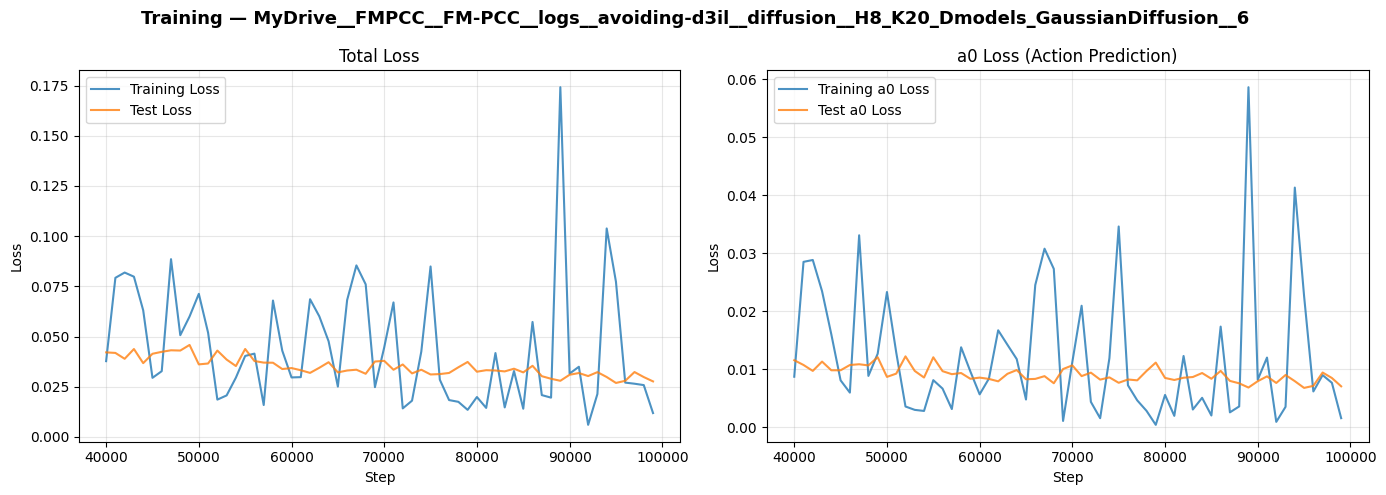


✅ Loss curves saved to /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6/MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__diffusion__H8_K20_Dmodels_GaussianDiffusion__6__loss_curves.png
--------------------------------------------------------------------------------
============================== FILE: model_config.pkl ==============================
FAILED TO LOAD model_config.pkl: No module named 'diffuser'
--------------------------------------------------------------------------------
============================== FILE: state_80000.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: state_60000.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: state

In [16]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── Fallback Unpickler ──
class FallbackUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if 'flow_matcher' in module:
            return type(name, (), {})
        return super().find_class(module, name)

# ── Target directory ──
target_dir = '/content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6'

path_parts = target_dir.rstrip('/').split('/')
identifier = '__'.join(path_parts[3:]).replace('Dmodels.diffusion.', '').replace('.', '_')
print(f"Run identifier: {identifier}\n")

all_files = [
    f for f in os.listdir(target_dir)
    if os.path.isfile(os.path.join(target_dir, f)) and ':' not in f
]

print(f"Found {len(all_files)} files in: {target_dir}\n")

for file_name in all_files:
    path = os.path.join(target_dir, file_name)
    print(f"{'='*30} FILE: {file_name} {'='*30}")

    try:
        # Handle NumPy Archive (.npz)
        if file_name.endswith('.npz'):
            with np.load(path, allow_pickle=True) as data:
                for key in data.files:
                    arr = data[key]
                    print(f"Key: {key:<20} | Shape: {str(arr.shape):<12} | Dtype: {arr.dtype}")
                    if arr.size > 0:
                        print(arr if arr.size < 10 else f"First 5: {arr.flatten()[:5]}...")

        # Handle Pickle Files (.pkl) — always use FallbackUnpickler
        elif file_name.endswith('.pkl'):
            with open(path, 'rb') as f:
                content = FallbackUnpickler(f).load()

            if isinstance(content, dict):
                for k, v in content.items():
                    print(f"{k:<25}: {v}")
            elif hasattr(content, '__dict__'):
                print(f"  Type: {type(content).__name__}")
                for k, v in vars(content).items():
                    print(f"  {k}: {v}")
            elif isinstance(content, (list, np.ndarray)):
                arr_content = np.array(content)
                print(f"Data Type: {type(content)} | Length: {len(arr_content)}")
                print(f"Last Values: {arr_content[-5:]}")
            else:
                print(content)

            # ── Plot loss curves if this is losses.pkl ──
            if file_name == 'losses.pkl' and isinstance(content, dict):
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                for key, label, color in [
                    ('training_losses', 'Training Loss', 'tab:blue'),
                    ('test_losses', 'Test Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[0].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[0].set_xlabel('Step')
                axes[0].set_ylabel('Loss')
                axes[0].set_title('Total Loss')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                for key, label, color in [
                    ('training_a0_losses', 'Training a0 Loss', 'tab:blue'),
                    ('test_a0_losses', 'Test a0 Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[1].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[1].set_xlabel('Step')
                axes[1].set_ylabel('Loss')
                axes[1].set_title('a0 Loss (Action Prediction)')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                plt.suptitle(f'Training — {identifier}', fontsize=13, fontweight='bold')
                plt.tight_layout()

                save_name = f'{identifier}__loss_curves.png'
                save_path = os.path.join(target_dir, save_name)
                plt.savefig(save_path, dpi=150)
                plt.show()
                print(f"\n✅ Loss curves saved to {save_path}")

        # Handle PyTorch Weights (.pt)
        elif file_name.endswith('.pt'):
            import torch
            checkpoint = torch.load(path, map_location='cpu')
            if isinstance(checkpoint, dict):
                print(f"Keys in Checkpoint: {list(checkpoint.keys())}")
            else:
                print("Raw Tensor/Object loaded.")

    except Exception as e:
        print(f"FAILED TO LOAD {file_name}: {e}")

    print("-" * 80)

Combined

Parsed 40 epoch lines from pasted text (steps 999 → 40000)
  training_losses: added 39 points from console, total 99 points
  test_losses: added 39 points from console, total 99 points
  training_a0_losses: added 39 points from console, total 99 points
  test_a0_losses: added 39 points from console, total 99 points


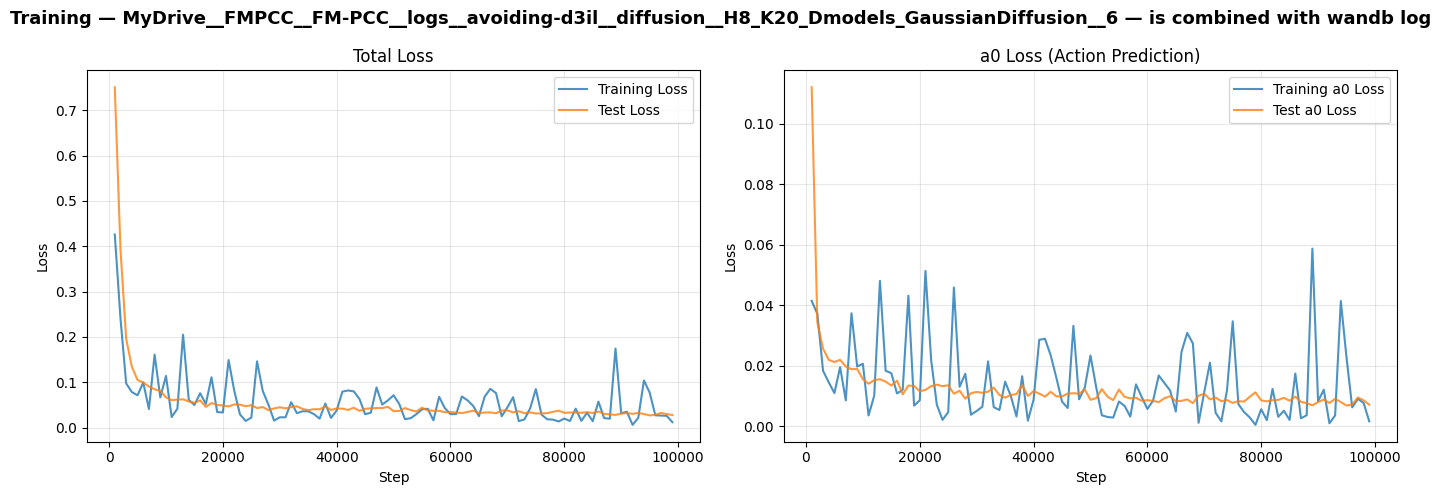


✅ Loss curves saved to /content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6/MyDrive__FMPCC__FM-PCC__logs__avoiding-d3il__diffusion__H8_K20_Dmodels_GaussianDiffusion__6__loss_curves__is_combined_with_wandb_log.png


In [26]:
import os, re, pickle
import numpy as np
import matplotlib.pyplot as plt

target_dir = '/content/drive/MyDrive/FMPCC/FM-PCC/logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/6'

class FallbackUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if "flow_matcher" in module:
            return type(name, (), {})
        return super().find_class(module, name)

def load_losses_pkl(path):
    with open(path, "rb") as f:
        d = FallbackUnpickler(f).load()
    out = {}
    for k, v in d.items():
        arr = np.array(v)
        if arr.ndim == 2 and arr.shape[1] == 2:
            out[k] = arr.astype(float)
    return out

pkl = load_losses_pkl(os.path.join(target_dir, "losses.pkl"))

# ---- Paste your full W&B console output here ----
WANDB_LOG_TEXT = r"""
Epoch 0: 100% 1000/1000 [01:21<00:00, 12.31it/s, a0_loss=0.0414, a0_loss_test=0.112, diffusion_loss=0.853, loss=0.426, loss_test=0.751, lr=0.0001, step=999]
2026-03-20 15:47:35
Initial test loss:   0.7509, a0 loss:   0.1115
2026-03-20 15:50:14
Epoch 1: 100% 1000/1000 [01:19<00:00, 12.57it/s, a0_loss=0.0371, a0_loss_test=0.0343, diffusion_loss=0.483, loss=0.241, loss_test=0.393, lr=0.0001, step=1999]
2026-03-20 15:51:34
Epoch 2: 100% 1000/1000 [01:20<00:00, 12.44it/s, a0_loss=0.0183, a0_loss_test=0.0256, diffusion_loss=0.195, loss=0.0975, loss_test=0.196, lr=9.99e-5, step=2999]
2026-03-20 15:52:56
Epoch 3: 100% 1000/1000 [01:21<00:00, 12.26it/s, a0_loss=0.0145, a0_loss_test=0.0219, diffusion_loss=0.157, loss=0.0783, loss_test=0.134, lr=9.98e-5, step=3999]
2026-03-20 15:54:20
Epoch 4: 100% 1000/1000 [01:25<00:00, 11.65it/s, a0_loss=0.0109, a0_loss_test=0.0212, diffusion_loss=0.142, loss=0.0712, loss_test=0.105, lr=9.96e-5, step=4999]
2026-03-20 15:55:45
Epoch 5: 100% 1000/1000 [01:23<00:00, 12.00it/s, a0_loss=0.0195, a0_loss_test=0.0219, diffusion_loss=0.199, loss=0.0993, loss_test=0.0995, lr=9.94e-5, step=5999]
2026-03-20 15:57:05
Epoch 6: 100% 1000/1000 [01:21<00:00, 12.32it/s, a0_loss=0.00851, a0_loss_test=0.0197, diffusion_loss=0.0818, loss=0.0409, loss_test=0.0904, lr=9.91e-5, step=6999]
2026-03-20 15:58:29
Epoch 7: 100% 1000/1000 [01:23<00:00, 12.05it/s, a0_loss=0.0373, a0_loss_test=0.0188, diffusion_loss=0.323, loss=0.161, loss_test=0.0845, lr=9.88e-5, step=7999]
2026-03-20 15:59:49
Epoch 8: 100% 1000/1000 [01:21<00:00, 12.28it/s, a0_loss=0.0197, a0_loss_test=0.0189, diffusion_loss=0.133, loss=0.0664, loss_test=0.0811, lr=9.84e-5, step=8999]
2026-03-20 16:01:11
Epoch 9: 100% 1000/1000 [01:20<00:00, 12.39it/s, a0_loss=0.0206, a0_loss_test=0.0155, diffusion_loss=0.228, loss=0.114, loss_test=0.0666, lr=9.8e-5, step=9999]
2026-03-20 16:02:32
Epoch 10: 100% 1000/1000 [01:21<00:00, 12.32it/s, a0_loss=0.00351, a0_loss_test=0.014, diffusion_loss=0.0464, loss=0.0232, loss_test=0.0603, lr=9.75e-5, step=10999]
2026-03-20 16:03:50
Epoch 11: 100% 1000/1000 [01:19<00:00, 12.65it/s, a0_loss=0.0101, a0_loss_test=0.0152, diffusion_loss=0.0833, loss=0.0416, loss_test=0.0617, lr=9.7e-5, step=11999]
2026-03-20 16:05:12
Epoch 12: 100% 1000/1000 [01:21<00:00, 12.25it/s, a0_loss=0.048, a0_loss_test=0.0155, diffusion_loss=0.41, loss=0.205, loss_test=0.0623, lr=9.64e-5, step=12999]
2026-03-20 16:06:34
Epoch 13: 100% 1000/1000 [01:21<00:00, 12.28it/s, a0_loss=0.0183, a0_loss_test=0.0147, diffusion_loss=0.123, loss=0.0613, loss_test=0.0576, lr=9.58e-5, step=13999]
2026-03-20 16:07:56
Epoch 14: 100% 1000/1000 [01:21<00:00, 12.20it/s, a0_loss=0.0175, a0_loss_test=0.0134, diffusion_loss=0.0995, loss=0.0498, loss_test=0.0547, lr=9.51e-5, step=14999]
2026-03-20 16:09:17
Epoch 15: 100% 1000/1000 [01:21<00:00, 12.34it/s, a0_loss=0.0108, a0_loss_test=0.015, diffusion_loss=0.152, loss=0.0758, loss_test=0.0599, lr=9.44e-5, step=15999]
2026-03-20 16:10:39
Epoch 16: 100% 1000/1000 [01:21<00:00, 12.32it/s, a0_loss=0.012, a0_loss_test=0.0105, diffusion_loss=0.104, loss=0.052, loss_test=0.0456, lr=9.37e-5, step=16999]
2026-03-20 16:11:59
Epoch 17: 100% 1000/1000 [01:19<00:00, 12.53it/s, a0_loss=0.0431, a0_loss_test=0.0134, diffusion_loss=0.222, loss=0.111, loss_test=0.0541, lr=9.29e-5, step=17999]
2026-03-20 16:13:19
Epoch 18: 100% 1000/1000 [01:20<00:00, 12.40it/s, a0_loss=0.00677, a0_loss_test=0.0133, diffusion_loss=0.0682, loss=0.0341, loss_test=0.0499, lr=9.21e-5, step=18999]
2026-03-20 16:14:41
Epoch 19: 100% 1000/1000 [01:23<00:00, 11.92it/s, a0_loss=0.00855, a0_loss_test=0.0115, diffusion_loss=0.0669, loss=0.0334, loss_test=0.0485, lr=9.12e-5, step=2e+4]
2026-03-20 16:16:06
Epoch 20: 100% 1000/1000 [01:22<00:00, 12.09it/s, a0_loss=0.0513, a0_loss_test=0.012, diffusion_loss=0.297, loss=0.149, loss_test=0.0467, lr=9.03e-5, step=20999]
2026-03-20 16:17:30
Epoch 21: 100% 1000/1000 [01:23<00:00, 11.93it/s, a0_loss=0.0219, a0_loss_test=0.0132, diffusion_loss=0.162, loss=0.0812, loss_test=0.051, lr=8.93e-5, step=21999]
2026-03-20 16:18:54
Epoch 22: 100% 1000/1000 [01:24<00:00, 11.77it/s, a0_loss=0.00705, a0_loss_test=0.0137, diffusion_loss=0.0584, loss=0.0292, loss_test=0.0504, lr=8.83e-5, step=22999]
2026-03-20 16:20:16
Epoch 23: 100% 1000/1000 [01:23<00:00, 12.05it/s, a0_loss=0.00206, a0_loss_test=0.0132, diffusion_loss=0.0291, loss=0.0146, loss_test=0.0471, lr=8.73e-5, step=23999]
2026-03-20 16:21:41
Epoch 24: 100% 1000/1000 [01:24<00:00, 11.89it/s, a0_loss=0.00462, a0_loss_test=0.0135, diffusion_loss=0.044, loss=0.022, loss_test=0.0493, lr=8.62e-5, step=24999]
2026-03-20 16:23:07
Epoch 25: 100% 1000/1000 [01:25<00:00, 11.64it/s, a0_loss=0.0458, a0_loss_test=0.0107, diffusion_loss=0.292, loss=0.146, loss_test=0.043, lr=8.51e-5, step=25999]
2026-03-20 16:24:31
Epoch 26: 100% 1000/1000 [01:24<00:00, 11.79it/s, a0_loss=0.013, a0_loss_test=0.0117, diffusion_loss=0.162, loss=0.0809, loss_test=0.0452, lr=8.39e-5, step=26999]
2026-03-20 16:25:57
Epoch 27: 100% 1000/1000 [01:25<00:00, 11.65it/s, a0_loss=0.0173, a0_loss_test=0.00904, diffusion_loss=0.101, loss=0.0505, loss_test=0.0384, lr=8.27e-5, step=27999]
2026-03-20 16:27:19
Epoch 28: 100% 1000/1000 [01:21<00:00, 12.20it/s, a0_loss=0.00377, a0_loss_test=0.0109, diffusion_loss=0.0308, loss=0.0154, loss_test=0.0423, lr=8.15e-5, step=28999]
2026-03-20 16:28:42
Epoch 29: 100% 1000/1000 [01:21<00:00, 12.28it/s, a0_loss=0.00501, a0_loss_test=0.0113, diffusion_loss=0.0453, loss=0.0226, loss_test=0.0448, lr=8.03e-5, step=3e+4]
2026-03-20 16:30:00
Epoch 30: 100% 1000/1000 [01:19<00:00, 12.61it/s, a0_loss=0.00641, a0_loss_test=0.011, diffusion_loss=0.0452, loss=0.0226, loss_test=0.0423, lr=7.9e-5, step=30999]
2026-03-20 16:31:22
Epoch 31: 100% 1000/1000 [01:21<00:00, 12.29it/s, a0_loss=0.0214, a0_loss_test=0.0114, diffusion_loss=0.112, loss=0.0559, loss_test=0.045, lr=7.77e-5, step=31999]
2026-03-20 16:32:46
Epoch 32: 100% 1000/1000 [01:23<00:00, 11.98it/s, a0_loss=0.00629, a0_loss_test=0.0127, diffusion_loss=0.0639, loss=0.0319, loss_test=0.0469, lr=7.64e-5, step=32999]
2026-03-20 16:34:06
Epoch 33: 100% 1000/1000 [01:20<00:00, 12.36it/s, a0_loss=0.00533, a0_loss_test=0.0103, diffusion_loss=0.0719, loss=0.0359, loss_test=0.0411, lr=7.5e-5, step=33999]
2026-03-20 16:35:31
Epoch 34: 100% 1000/1000 [01:23<00:00, 11.93it/s, a0_loss=0.0147, a0_loss_test=0.00941, diffusion_loss=0.0718, loss=0.0359, loss_test=0.0385, lr=7.36e-5, step=34999]
2026-03-20 16:36:51
Epoch 35: 100% 1000/1000 [01:20<00:00, 12.35it/s, a0_loss=0.00997, a0_loss_test=0.0103, diffusion_loss=0.0593, loss=0.0297, loss_test=0.0405, lr=7.22e-5, step=35999]
2026-03-20 16:38:13
Epoch 36: 100% 1000/1000 [01:23<00:00, 12.04it/s, a0_loss=0.00317, a0_loss_test=0.0106, diffusion_loss=0.0394, loss=0.0197, loss_test=0.0404, lr=7.08e-5, step=36999]
2026-03-20 16:39:41
Epoch 37: 100% 1000/1000 [01:26<00:00, 11.56it/s, a0_loss=0.0165, a0_loss_test=0.0136, diffusion_loss=0.106, loss=0.053, loss_test=0.0464, lr=6.93e-5, step=37999]
2026-03-20 16:41:01
Epoch 38: 100% 1000/1000 [01:21<00:00, 12.25it/s, a0_loss=0.00179, a0_loss_test=0.00996, diffusion_loss=0.0426, loss=0.0213, loss_test=0.0389, lr=6.78e-5, step=38999]
2026-03-20 16:42:26
Epoch 39: 100% 1000/1000 [01:23<00:00, 11.95it/s, a0_loss=0.011, a0_loss_test=0.00984, diffusion_loss=0.0917, loss=0.0459, loss_test=0.0381, lr=6.64e-5, step=4e+4]
2026-03-20 16:43:50
""".strip()

# ---- Parse ----
def parse_console(text):
    text = re.sub(r"(?=\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})", "\n", text)
    rows = []
    for line in text.splitlines():
        if "Epoch" not in line or "step=" not in line:
            continue
        def grab(pat):
            m = re.search(pat, line)
            return float(m.group(1)) if m else np.nan
        step = grab(r"step=([0-9]+(?:\.[0-9]+)?(?:e\+?[0-9]+)?)")
        if np.isnan(step):
            continue
        step = int(step)
        rows.append((
            step,
            grab(r"(?<!\w)loss=([0-9]+(?:\.[0-9]+)?(?:e[+-]?[0-9]+)?)"),
            grab(r"(?<!\w)loss_test=([0-9]+(?:\.[0-9]+)?(?:e[+-]?[0-9]+)?)"),
            grab(r"(?<!\w)a0_loss=([0-9]+(?:\.[0-9]+)?(?:e[+-]?[0-9]+)?)"),
            grab(r"a0_loss_test=([0-9]+(?:\.[0-9]+)?(?:e[+-]?[0-9]+)?)"),
        ))
    if not rows:
        raise ValueError("No rows parsed.")
    return np.array(sorted(rows, key=lambda x: x[0]), dtype=float)

w = parse_console(WANDB_LOG_TEXT)
print(f"Parsed {len(w)} epoch lines from pasted text (steps {int(w[0,0])} → {int(w[-1,0])})")

# ---- Combine: only add steps NOT already in pkl ----
def combine(local_arr, extra_steps, extra_vals):
    local_steps = local_arr[:, 0].astype(int)
    local_vals  = local_arr[:, 1].astype(float)
    local_set = set(local_steps.tolist())
    fin = np.isfinite(extra_vals)
    keep = np.array([s not in local_set for s in extra_steps]) & fin
    all_s = np.concatenate([extra_steps[keep], local_steps])
    all_v = np.concatenate([extra_vals[keep],  local_vals])
    order = np.argsort(all_s)
    return np.c_[all_s[order], all_v[order]], int(keep.sum())

# mapping: pkl key → column index in parsed array
SPECS = [
    ("training_losses",    1),
    ("test_losses",        2),
    ("training_a0_losses", 3),
    ("test_a0_losses",     4),
]

combined = {}
for pkl_key, col in SPECS:
    combined[pkl_key], added = combine(pkl[pkl_key], w[:,0].astype(int), w[:,col])
    print(f"  {pkl_key}: added {added} points from console, total {len(combined[pkl_key])} points")

# ---- Plot: 2 subplots, each with 2 curves (train + test) ----
path_parts = target_dir.rstrip("/").split("/")
identifier = "__".join(path_parts[3:]).replace("Dmodels.diffusion.", "").replace(".", "_")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Total Loss
for key, label, color in [
    ("training_losses", "Training Loss", "tab:blue"),
    ("test_losses",     "Test Loss",     "tab:orange"),
]:
    data = combined[key]
    axes[0].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Total Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: a0 Loss
for key, label, color in [
    ("training_a0_losses", "Training a0 Loss", "tab:blue"),
    ("test_a0_losses",     "Test a0 Loss",     "tab:orange"),
]:
    data = combined[key]
    axes[1].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].set_title("a0 Loss (Action Prediction)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Training — {identifier} — is combined with wandb log", fontsize=13, fontweight="bold")
plt.tight_layout()

save_name = f"{identifier}__loss_curves__is_combined_with_wandb_log.png"
save_path = os.path.join(target_dir, save_name)
plt.savefig(save_path, dpi=150)
plt.show()
print(f"\n✅ Loss curves saved to {save_path}")

## Load the Plan .npz logs

In [ ]:
import numpy as np

# Path to your specific file
file_path = ''

# allow_pickle=True is MANDATORY for 'object' dtypes in npz
# Using a context manager ('with') is safer for file I/O
with np.load(file_path, allow_pickle=True) as data:

    # Force NumPy to print the entire array instead of truncating with "..."
    np.set_printoptions(threshold=np.inf, precision=6, suppress=True)

    print(f"{'Key':<25} | {'Shape':<15} | {'Data Type':<10}")
    print("=" * 60)

    for key in data.files:
        array = data[key]

        # Header for each entry
        print(f"{key:<25} | {str(array.shape):<15} | {str(array.dtype):<10}")

        # Logic to handle potential object arrays or nested dicts
        if array.dtype == 'object':
            print("--- Object Content ---")
            print(array.tolist()) # Converting to list often reveals the internal structure
        else:
            print(array)

        print("-" * 60)